<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/main/Tercer_entregable_Rebeca_Alvarez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

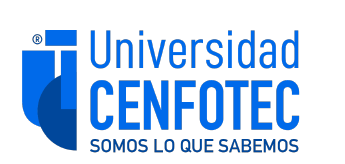

Estudiante: Rebeca Alvarez

Universidad CENFOTEC

Curso: Proyecto Integrador en IA

Nombre del Profesor a Cargo: Alexander Bermudez

Fecha: Mayo, 2026

#**Descripción del dataset original**

In [ ]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [ ]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# =========================
# 1. Cargar dataset
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DESCRIPCIÓN GENERAL DEL DATASET")
print("-" * 50)
print("Filas y columnas:", df.shape)
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

DESCRIPCIÓN GENERAL DEL DATASET
--------------------------------------------------
Filas y columnas: (28332, 24)
Cantidad de filas: 28332
Cantidad de columnas: 24

Columnas del dataset:
['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']

Primeras filas:


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doReco

##1. Resumen de tipos de variables

In [ ]:
# =========================
# 2. Tipos de variables
# =========================

tipos_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str),
    "Valores no nulos": df.notnull().sum().values,
    "Valores nulos": df.isnull().sum().values,
    "Porcentaje nulos": ((df.isnull().sum() / len(df)) * 100).round(2).values,
    "Valores únicos": df.nunique(dropna=False).values
})

display(tipos_variables)

,Variable,Tipo de dato,Valores no nulos,Valores nulos,Porcentaje nulos,Valores únicos
id,id,object,28332,0,0.00,65
dateAdded,dateAdded,object,28332,0,0.00,55
dateUpdated,dateUpdated,object,28332,0,0.00,52
name,name,object,28332,0,0.00,65
asins,asins,object,28332,0,0.00,65
brand,brand,object,28332,0,0.00,3
categories,categories,object,28332,0,0.00,60
primaryCategories,primaryCategories,object,28332,0,0.00,9
imageURLs,imageURLs,object,28332,0,0.00,65
keys,keys,object,28332,0,0.00,65


##Análisis de variables altamente correlacionadas

(Los problemas de cardinalidad alta, desbalance de clases y escalas inconsistentes se tomaron del avance anterior, y se documentaron en el documento de word)



In [ ]:
import pandas as pd

df = pd.read_csv("Amazon_Consumer_Review.csv")

# =========================
# 3. Crear variables numéricas auxiliares
# =========================

df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Variables numéricas disponibles
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Variables numéricas detectadas:")
print(numeric_df.columns.tolist())

# =========================
# 4. Matriz de correlación
# =========================

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))

# =========================
# 5. Identificar correlaciones altas
# =========================

correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlación consigo misma
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Evitar duplicados
correlation_pairs["Par ordenado"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par ordenado")
correlation_pairs = correlation_pairs.drop(columns=["Par ordenado"])

# Filtrar correlaciones fuertes
high_correlations = correlation_pairs[
    correlation_pairs["Correlación"].abs() >= 0.70
].sort_values(by="Correlación", ascending=False)

print("Variables altamente correlacionadas:")
display(high_correlations.round(3))

Variables numéricas detectadas:
['reviews.id', 'reviews.numHelpful', 'reviews.rating', 'review_length_chars', 'review_length_words']


,reviews.id,reviews.numHelpful,reviews.rating,review_length_chars,review_length_words
reviews.id,1.000,-0.554,0.075,-0.009,-0.016
reviews.numHelpful,-0.554,1.000,-0.041,0.237,0.233
reviews.rating,0.075,-0.041,1.000,-0.120,-0.120
review_length_chars,-0.009,0.237,-0.120,1.000,0.997
review_length_words,-0.016,0.233,-0.120,0.997,1.000


Variables altamente correlacionadas:


,Variable 1,Variable 2,Correlación
19,review_length_chars,review_length_words,0.997


In [ ]:
#Vamos a modificar la columna reviews.username a que sea string, para que pueda ser parte de las correlaciones
# Reemplazar nulos y convertir a texto
df["reviews.username"] = df["reviews.username"].fillna("unknown").astype("string")

# Verificar resultado
print(df["reviews.username"].dtype)
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# Convertir reviews.username a tipo texto/string
df["reviews.username"] = df["reviews.username"].astype("string")

# Verificar el tipo de dato
print(df["reviews.username"].dtype)

# Ver primeras filas
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# =========================
# 6. Asociación entre variables de texto (Cramér's V + coincidencia + tablas cruzadas)
# =========================

from scipy.stats import chi2_contingency
import numpy as np
import itertools

text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")


def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)

print("Resumen de asociación entre variables categóricas:")
display(summary_df.sort_values("Cramér's V", ascending=False).round(4))

# Mostrar tablas cruzadas para revisar posibles réplicas
for r in results:
    print(f"\nTabla cruzada: {r['Variable 1']} vs {r['Variable 2']}")
    display(r["Tabla cruzada"])



Resumen de asociación entre variables categóricas:


,Variable 1,Variable 2,Cramér's V,% coincidencia
0,brand,manufacturer,0.7071,99.9188
1,brand,reviews.username,0.6524,0.0035
2,manufacturer,reviews.username,0.6129,0.0035



Tabla cruzada: brand vs manufacturer


manufacturer,Amazon,Amazon Digital Services,Amazon.com,AmazonBasics
brand,,,,
Amazon,16130,18,5,0
AmazonBasics,0,0,0,10
Amazonbasics,0,0,0,12169



Tabla cruzada: brand vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
brand,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazonbasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Tabla cruzada: manufacturer vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
manufacturer,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
Amazon Digital Services,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazon.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Interpretación de los resultados**

Estos resultados analizan la asociación entre variables categóricas usando Cramér’s V y porcentaje de coincidencia. En general, muestran que existe una relación fuerte entre brand y manufacturer, mientras que las asociaciones con reviews.username deben interpretarse con mucha cautela por su alta cardinalidad.

1. Asociación entre brand y manufacturer

| Variable 1 | Variable 2     | Cramér’s V | % coincidencia |
| ---------- | -------------- | ---------: | -------------: |
| `brand`    | `manufacturer` |     0.7071 |       99.9188% |


El valor de Cramér’s V = 0.7071 indica una asociación alta entre brand y manufacturer.

Además, el porcentaje de coincidencia es de 99.9188%, lo cual significa que ambas variables contienen prácticamente la misma información en casi todos los registros.

La tabla cruzada confirma esto:

| brand        | Amazon | Amazon Digital Services | Amazon.com | AmazonBasics |
| ------------ | -----: | ----------------------: | ---------: | -----------: |
| Amazon       |  16130 |                      18 |          5 |            0 |
| AmazonBasics |      0 |                       0 |          0 |           10 |
| Amazonbasics |      0 |                       0 |          0 |        12169 |


La mayoría de registros con brand = Amazon tienen manufacturer = Amazon. De igual forma, brand = Amazonbasics se asocia casi completamente con manufacturer = AmazonBasics.

Conclusión

brand y manufacturer son variables altamente redundantes.

Para el modelo, no es necesario usar ambas. Se recomienda conservar solo una para evitar duplicidad de información.

Para mi modelo, conservaré brand, porque es más clara desde el punto de vista de negocio y suele representar mejor la identidad comercial del producto.

También conviene normalizar valores como:

AmazonBasics
Amazonbasics

porque representan probablemente la misma marca, pero están escritos con diferente capitalización.

2. Asociación entre brand y reviews.username

| Variable 1 | Variable 2         | Cramér’s V | % coincidencia |
| ---------- | ------------------ | ---------: | -------------: |
| `brand`    | `reviews.username` |     0.6524 |        0.0035% |


A primera vista, Cramér’s V = 0.6524 parece indicar una asociación moderada-alta. Sin embargo, el porcentaje de coincidencia es prácticamente cero: 0.0035%.

Esto ocurre porque reviews.username tiene una cardinalidad extremadamente alta: la tabla muestra 16,269 columnas, una por cada usuario.

Cuando una variable categórica tiene muchísimos valores únicos, Cramér’s V puede dar una impresión inflada de asociación, especialmente si muchos usuarios aparecen pocas veces o solo asociados a una marca por casualidad.

En otras palabras, la asociación no necesariamente significa que el usuario explique la marca o que sea útil para el modelo. Puede ser un efecto estadístico causado por la alta cardinalidad.

Conclusión

reviews.username no debe considerarse una variable útil para el modelo.

Aunque Cramér’s V parece alto, la variable tiene demasiadas categorías, baja generalización y puede introducir ruido.

En mi modelo voy a excluir reviews.username del modelo predictivo.

Razones:

alta cardinalidad;
poco valor predictivo generalizable;
riesgo de sobreajuste;
posible problema de privacidad;
no aporta lógica de negocio directa para predecir caída en desempeño.

3. Asociación entre manufacturer y reviews.username

| Variable 1     | Variable 2         | Cramér’s V | % coincidencia |
| -------------- | ------------------ | ---------: | -------------: |
| `manufacturer` | `reviews.username` |     0.6129 |        0.0035% |


Interpretación

El caso es similar al anterior. El valor de Cramér’s V = 0.6129 puede parecer alto, pero está influenciado por la alta cardinalidad de reviews.username.

La tabla cruzada muestra muchísimos usuarios, y casi todos se concentran bajo manufacturer = Amazon, porque el dataset está dominado por productos de Amazon.

Esto no significa que reviews.username sea una buena variable predictiva. Significa más bien que muchos usuarios aparecen en un dataset donde casi todos los productos pertenecen a Amazon o AmazonBasics.

Conclusión

La asociación entre manufacturer y reviews.username no debe usarse como argumento para conservar reviews.username.

La relación es poco útil desde el punto de vista predictivo y puede generar sobreajuste.

4. Hallazgos principales

| Hallazgo                                              | Interpretación                       | Decisión recomendada               |
| ----------------------------------------------------- | ------------------------------------ | ---------------------------------- |
| `brand` y `manufacturer` están altamente asociados    | Contienen información casi duplicada | Conservar solo una                 |
| `brand` y `manufacturer` tienen 99.9% de coincidencia | Son variables redundantes            | Preferir `brand`                   |
| `reviews.username` tiene cardinalidad extrema         | Más de 16,000 usuarios únicos        | Excluir del modelo                 |
| Cramér’s V con `reviews.username` parece alto         | Puede estar inflado por cardinalidad | No interpretarlo como señal fuerte |
| `AmazonBasics` y `Amazonbasics` aparecen separados    | Problema de consistencia textual     | Estandarizar capitalización        |


5. Implicación para mi modelo

Si incluye brand, manufacturer y reviews.username al mismo tiempo, puede generar:

redundancia;
demasiadas columnas por One-Hot Encoding;
sobreajuste;
baja interpretabilidad;
aumento innecesario de dimensionalidad.

La Regresión Logística asigna un coeficiente a cada variable. Si se incluyen variables redundantes, como brand y manufacturer, los coeficientes pueden volverse menos estables. Si se incluye reviews.username, el modelo puede aprender patrones específicos de usuarios que no se repiten en nuevos datos.

6. Decisión final

| Variable           | Decisión  | Justificación                                             |
| ------------------ | --------- | --------------------------------------------------------- |
| `brand`            | Conservar | Clara, interpretable y útil para segmentación.            |
| `manufacturer`     | Eliminar  | Redundante con `brand`.                                   |
| `reviews.username` | Eliminar  | Alta cardinalidad, riesgo de sobreajuste y baja utilidad. |
.


#Graficos de visualización

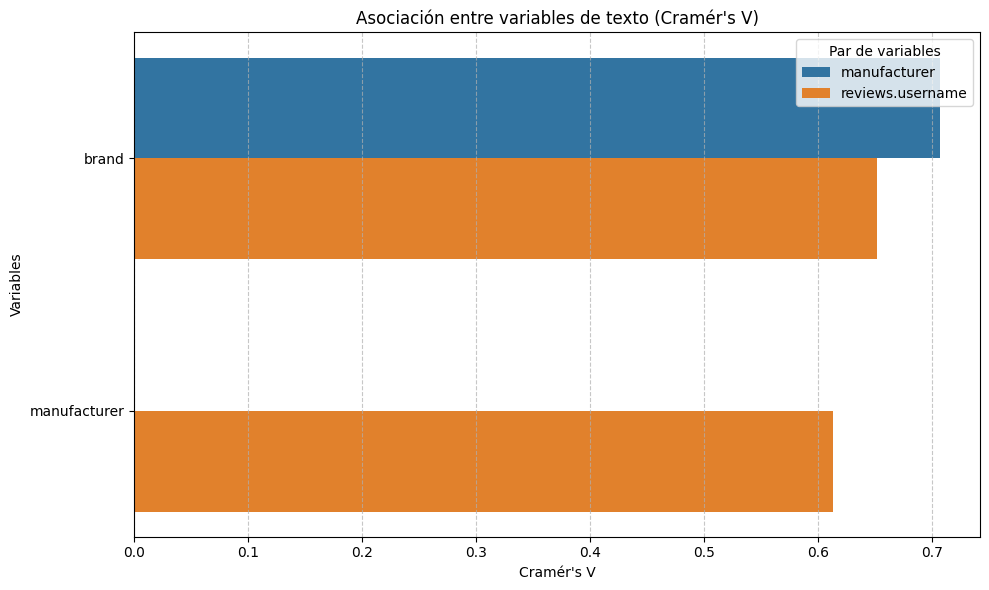

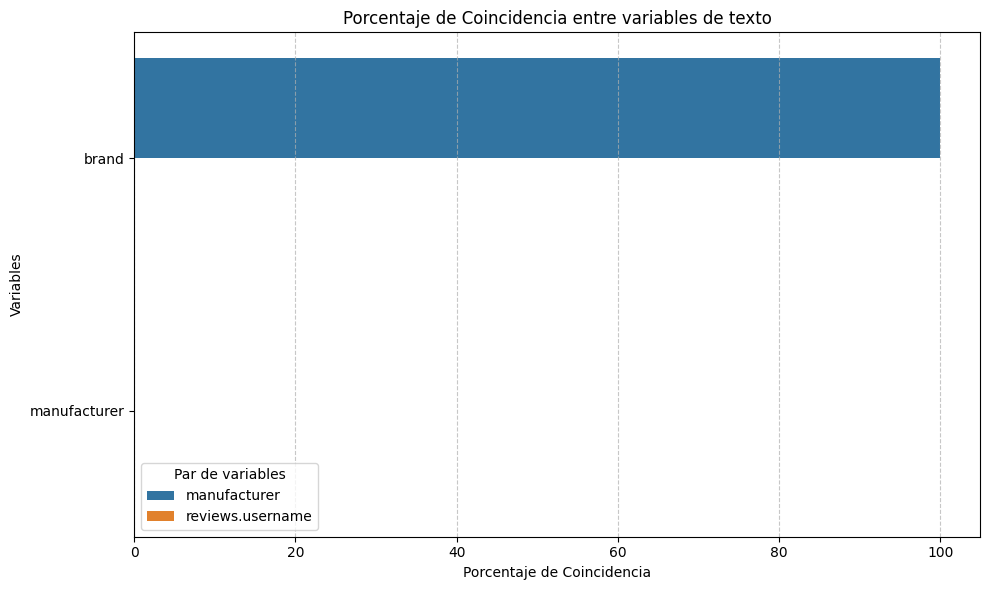

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import itertools

# --- Code to define summary_df ---
text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")

def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada (not strictly needed for summary_df, but part of original logic)
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)
# --- End of code to define summary_df ---

# =========================
# 6.1. Visualización de Cramér's V
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="Cramér's V", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("Cramér's V", ascending=False))
plt.title("Asociación entre variables de texto (Cramér's V)")
plt.xlabel("Cramér's V")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================
# 6.2. Visualización de % coincidencia
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="% coincidencia", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("% coincidencia", ascending=False))
plt.title("Porcentaje de Coincidencia entre variables de texto")
plt.xlabel("Porcentaje de Coincidencia")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Conclusion final

El dataset original es adecuado para analizar patrones de reseñas negativas y construir indicadores de riesgo asociados al desempeño de productos. Contiene texto, ratings, fechas, productos y categorías, lo cual permite generar variables útiles para evaluar la percepción del consumidor.
Sin embargo, el dataset tiene una limitación fundamental: no incluye datos reales de ventas. Por lo tanto, el proyecto no podrá predecir una caída de ventas en sentido estricto, sino un riesgo de caída de ventas basado en señales indirectas de insatisfacción del cliente.
Los principales problemas identificados son el desbalance de clases, la alta concentración de reseñas positivas, la presencia de variables con muchos nulos, la alta cardinalidad en variables de producto y usuario, variables potencialmente redundantes y escalas inconsistentes entre variables numéricas.
A pesar de estas limitaciones, el dataset es utilizable si se redefine correctamente el problema como una predicción de riesgo. Para ello, será necesario construir variables agregadas por producto y periodo, identificar reseñas negativas, analizar cambios en el rating promedio y usar modelos capaces de detectar patrones asociados a deterioro en la percepción del producto.


#**Ingeniería de características estándar**

A continuación presentaré 3 propuestas en Python, dependientes entre sí para crear features estándar usando su dataset de reseñas de Amazon, adaptado al nuevo enfoque: predecir riesgo de caída de ventas de un producto con base en reseñas negativas.


Limpieza inicial

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Cargar dataset original
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DATASET ORIGINAL")
print("Shape:", df.shape)
display(df.head())

# =========================
# 2. Limpieza inicial
# =========================

# Convertir fechas
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")

# Convertir numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(
    df["reviews.numHelpful"],
    errors="coerce"
).fillna(0)

# Eliminar columnas con demasiados nulos, si existen
columnas_eliminar = ["reviews.didPurchase", "reviews.id"]

df = df.drop(
    columns=[col for col in columnas_eliminar if col in df.columns],
    errors="ignore"
)

# =========================
# 3. Features básicas por reseña
# =========================

# Texto combinado
df["review_full_text"] = (
    df["reviews.title"].astype(str) + " " + df["reviews.text"].astype(str)
)

# Longitud del texto
df["review_length_chars"] = df["review_full_text"].apply(len)
df["review_length_words"] = df["review_full_text"].apply(lambda x: len(x.split()))

# Variables temporales
df["review_year"] = df["reviews.date"].dt.year
df["review_month"] = df["reviews.date"].dt.month
df["review_quarter"] = df["reviews.date"].dt.quarter
df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)

# Variables binarias de satisfacción
df["is_negative_review"] = np.where(df["reviews.rating"] <= 2, 1, 0)
df["is_neutral_review"] = np.where(df["reviews.rating"] == 3, 1, 0)
df["is_positive_review"] = np.where(df["reviews.rating"] >= 4, 1, 0)

# Variable de no recomendación
df["not_recommended"] = np.where(df["reviews.doRecommend"] == False, 1, 0)

print("DESPUÉS DE FEATURES POR RESEÑA")
print("Shape:", df.shape)
display(df[[
    "name",
    "reviews.rating",
    "reviews.date",
    "review_length_words",
    "is_negative_review",
    "not_recommended",
    "year_month"
]].head())

DATASET ORIGINAL
Shape: (28332, 24)


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


DESPUÉS DE FEATURES POR RESEÑA
Shape: (28332, 33)


/tmp/ipykernel_31620/398291734.py:52: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)


,name,reviews.rating,reviews.date,review_length_words,is_negative_review,not_recommended,year_month
0,AmazonBasics AAA Performance Alkaline Batterie...,3,2017-03-02 00:00:00+00:00,51,0,0,2017-03
1,AmazonBasics AAA Performance Alkaline Batterie...,4,2016-08-31 00:00:00+00:00,24,0,0,2016-08
2,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-12-06 00:00:00+00:00,23,0,0,2016-12
3,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-03-28 00:00:00+00:00,25,0,0,2016-03
4,AmazonBasics AAA Performance Alkaline Batterie...,5,2017-04-22 00:00:00+00:00,20,0,0,2017-04


##Propuesta 1. Features agregadas por producto

In [ ]:
product_features = df.groupby("name").agg(
    total_reviews=("reviews.rating", "count"),
    avg_rating=("reviews.rating", "mean"),
    min_rating=("reviews.rating", "min"),
    max_rating=("reviews.rating", "max"),
    negative_reviews=("is_negative_review", "sum"),
    neutral_reviews=("is_neutral_review", "sum"),
    positive_reviews=("is_positive_review", "sum"),
    not_recommended_count=("not_recommended", "sum"),
    avg_helpful_votes=("reviews.numHelpful", "mean"),
    total_helpful_votes=("reviews.numHelpful", "sum"),
    avg_review_length_words=("review_length_words", "mean"),
    first_review_date=("reviews.date", "min"),
    last_review_date=("reviews.date", "max")
).reset_index()

# =========================
# Añadir Brand y Primary Categories a product_features
# =========================
# Estas columnas son atributos a nivel de producto.
product_brand_category = df[['name', 'brand', 'primaryCategories']].drop_duplicates(subset=['name'])

# Fusionar con product_features
product_features = product_features.merge(
    product_brand_category,
    on='name',
    how='left'
)

# Ratios por producto
product_features["negative_review_rate"] = (
    product_features["negative_reviews"] / product_features["total_reviews"]
)

product_features["positive_review_rate"] = (
    product_features["positive_reviews"] / product_features["total_reviews"]
)

product_features["not_recommended_rate"] = (
    product_features["not_recommended_count"] / product_features["total_reviews"]
)

# Antigüedad en días
product_features["review_period_days"] = (
    product_features["last_review_date"] - product_features["first_review_date"]
).dt.days

# Frecuencia de reseñas
product_features["review_frequency"] = (
    product_features["total_reviews"] /
    product_features["review_period_days"].replace(0, np.nan)
)

print("FEATURES POR PRODUCTO")
print("Shape:", product_features.shape)
display(product_features.head())

FEATURES POR PRODUCTO
Shape: (65, 21)


,name,total_reviews,avg_rating,min_rating,max_rating,negative_reviews,neutral_reviews,positive_reviews,not_recommended_count,avg_helpful_votes,...,avg_review_length_words,first_review_date,last_review_date,brand,primaryCategories,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",82,4.585366,1,5,2,2,78,3,0.573171,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.024390,0.951220,0.036585,308.0,0.266234
1,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",233,4.630901,1,5,9,10,214,12,0.454936,...,41.000000,2017-06-15 00:00:00+00:00,2018-09-10 00:32:46+00:00,Amazon,Electronics,0.038627,0.918455,0.051502,452.0,0.515487
2,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",293,4.641638,1,5,6,11,276,9,0.313993,...,34.044369,2017-06-21 00:00:00+00:00,2018-05-25 00:00:00+00:00,Amazon,Electronics,0.020478,0.941980,0.030717,338.0,0.866864
3,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",883,4.578709,1,5,15,45,823,34,0.285391,...,31.682899,2017-06-20 00:00:00+00:00,2018-05-26 00:00:00+00:00,Amazon,Electronics,0.016988,0.932050,0.038505,340.0,2.597059
4,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",160,4.600000,1,5,5,2,153,9,0.731250,...,35.906250,2017-06-07 00:00:00+00:00,2018-05-22 00:00:00+00:00,Amazon,Electronics,0.031250,0.956250,0.056250,349.0,0.458453


##Propuesta 2: Features temporales producto-mes

In [ ]:
monthly_product = df.groupby(["name", "year_month"]).agg(
    monthly_reviews=("reviews.rating", "count"),
    monthly_avg_rating=("reviews.rating", "mean"),
    monthly_negative_reviews=("is_negative_review", "sum"),
    monthly_positive_reviews=("is_positive_review", "sum"),
    monthly_not_recommended=("not_recommended", "sum"),
    monthly_avg_helpful=("reviews.numHelpful", "mean"),
    monthly_avg_length_words=("review_length_words", "mean")
).reset_index()

# =========================
# 3. Añadir Brand y Primary Categories
# =========================
# Estas variables son a nivel de producto y se pueden añadir directamente.
monthly_product = monthly_product.merge(
    product_features[['name', 'brand', 'primaryCategories']],
    on='name',
    how='left'
)

# Ratios mensuales
monthly_product["monthly_negative_rate"] = (
    monthly_product["monthly_negative_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_positive_rate"] = (
    monthly_product["monthly_positive_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_not_recommended_rate"] = (
    monthly_product["monthly_not_recommended"] / monthly_product["monthly_reviews"]
)

# Orden temporal
monthly_product["year_month_date"] = pd.to_datetime(monthly_product["year_month"])
monthly_product = monthly_product.sort_values(["name", "year_month_date"])

# Lags
monthly_product["prev_month_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"].shift(1)
)

monthly_product["prev_month_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"].shift(1)
)

# Diferencias
monthly_product["rating_change"] = (
    monthly_product["monthly_avg_rating"] - monthly_product["prev_month_avg_rating"]
)

monthly_product["negative_rate_change"] = (
    monthly_product["monthly_negative_rate"] - monthly_product["prev_month_negative_rate"]
)

# Rolling windows de 3 meses
monthly_product["rolling_3m_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

monthly_product["rolling_3m_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

print("FEATURES PRODUCTO-MES")
print("Shape:", monthly_product.shape)
display(monthly_product.head(10))

FEATURES PRODUCTO-MES
Shape: (561, 21)


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand,...,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,year_month_date,prev_month_avg_rating,prev_month_negative_rate,rating_change,negative_rate_change,rolling_3m_avg_rating,rolling_3m_negative_rate
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,0.00000,1.000000,0.000000,2017-06-01,NaN,NaN,NaN,NaN,5.000000,0.00000
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,0.00000,1.000000,0.000000,2017-07-01,5.000000,0.00000,-0.400000,0.00000,4.800000,0.00000
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,0.00000,0.888889,0.111111,2017-08-01,4.600000,0.00000,-0.377778,0.00000,4.607407,0.00000
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,0.00000,1.000000,0.000000,2017-09-01,4.222222,0.00000,0.444444,0.00000,4.496296,0.00000
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,0.00000,1.000000,0.000000,2017-10-01,4.666667,0.00000,0.333333,0.00000,4.629630,0.00000
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,4.634146,2,39,2,0.000000,22.097561,Amazon,...,0.04878,0.951220,0.048780,2017-12-01,5.000000,0.00000,-0.365854,0.04878,4.766938,0.01626
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,4.545455,0,11,0,0.000000,22.636364,Amazon,...,0.00000,1.000000,0.000000,2018-01-01,4.634146,0.04878,-0.088692,-0.04878,4.726534,0.01626
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,4.800000,0,5,0,0.000000,26.600000,Amazon,...,0.00000,1.000000,0.000000,2018-02-01,4.545455,0.00000,0.254545,0.00000,4.659867,0.01626
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,4.250000,0,3,0,0.000000,31.500000,Amazon,...,0.00000,0.750000,0.000000,2018-03-01,4.800000,0.00000,-0.550000,0.00000,4.531818,0.00000
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,5.000000,0,2,0,0.000000,15.000000,Amazon,...,0.00000,1.000000,0.000000,2018-04-01,4.250000,0.00000,0.750000,0.00000,4.683333,0.00000


##Propuesta 3: Combinar features de producto con producto-mes

In [ ]:
final_dataset = monthly_product.merge(
    product_features,
    on="name",
    how="left"
)

print("DATASET FINAL COMBINADO")
print("Shape:", final_dataset.shape)
print("Columnas:", final_dataset.columns.tolist())
display(final_dataset.head())

DATASET FINAL COMBINADO
Shape: (561, 41)
Columnas: ['name', 'year_month', 'monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'brand_x', 'primaryCategories_x', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'brand_y', 'primaryCategories_y', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency']


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,avg_review_length_words,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234


##Crear variable proxy de riesgo

Como el dataset no tiene ventas reales, se crea una variable proxy llamada sales_drop_risk.

In [ ]:
import pandas as pd # Ensure pandas is imported for DataFrame operations
import numpy as np # Ensure numpy is imported for np.where

try:
    # Check if monthly_avg_rating and monthly_negative_rate are in final_dataset.
    # If not, merge them back from monthly_product (assuming monthly_product is correctly defined upstream).
    if 'monthly_avg_rating' not in final_dataset.columns or 'monthly_negative_rate' not in final_dataset.columns:
        print("Warning: 'monthly_avg_rating' or 'monthly_negative_rate' missing from final_dataset. Attempting to merge from monthly_product.")
        # Need to ensure 'monthly_product' is available and correctly structured

        if 'monthly_product' not in locals() and 'monthly_product' not in globals():
            raise NameError("La variable 'monthly_product' no está definida. Asegúrate de ejecutar la celda '_ikbmSUDyyXS'.")

        # Ensure final_dataset is sorted before any merge for consistent results
        final_dataset = final_dataset.sort_values(by=['name', 'year_month']).reset_index(drop=True)

        # Merge monthly_avg_rating if missing
        if 'monthly_avg_rating' not in final_dataset.columns:
            final_dataset = pd.merge(
                final_dataset,
                monthly_product[['name', 'year_month', 'monthly_avg_rating']],
                on=['name', 'year_month'],
                how='left'
            )
            print("Merged 'monthly_avg_rating' from monthly_product.")

        # Merge monthly_negative_rate if missing
        if 'monthly_negative_rate' not in final_dataset.columns:
            final_dataset = pd.merge(
                final_dataset,
                monthly_product[['name', 'year_month', 'monthly_negative_rate']],
                on=['name', 'year_month'],
                how='left'
            )
            print("Merged 'monthly_negative_rate' from monthly_product.")

    # Re-calculate 'rating_change' and 'negative_rate_change' based on current and previous month's values.
    # These calculations now rely on 'monthly_avg_rating' and 'monthly_negative_rate' which are ensured to be present.

    # Ensure sorting for correct shift/diff operations
    final_dataset = final_dataset.sort_values(by=['name', 'year_month']).reset_index(drop=True)

    # Re-calculate rating_change (diff between current monthly_avg_rating and previous month's monthly_avg_rating)
    # We re-calculate unconditionally to ensure correctness, as its presence earlier might have been flawed.
    final_dataset['rating_change'] = final_dataset.groupby('name')['monthly_avg_rating'].diff(1)

    # Re-calculate negative_rate_change (diff between current monthly_negative_rate and previous month's monthly_negative_rate)
    final_dataset['negative_rate_change'] = final_dataset.groupby('name')['monthly_negative_rate'].diff(1)

    # Re-calculate rolling_3m_negative_rate
    final_dataset['rolling_3m_negative_rate'] = (
        final_dataset.groupby('name')['monthly_negative_rate']
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # Now create lagged versions of the features that will define the target for the CURRENT month.
    # The target for a given row (month M) is defined by values from the previous month (M-1).
    final_dataset['prev_rating_change_for_target'] = final_dataset.groupby('name')['rating_change'].shift(1)
    final_dataset['prev_negative_rate_change_for_target'] = final_dataset.groupby('name')['negative_rate_change'].shift(1)
    final_dataset['prev_rolling_3m_negative_rate_for_target'] = final_dataset.groupby('name')['rolling_3m_negative_rate'].shift(1)
    final_dataset['prev_monthly_avg_rating_for_target'] = final_dataset.groupby('name')['monthly_avg_rating'].shift(1)

    # Define sales_drop_risk for the current month based on previous month's metrics
    final_dataset["sales_drop_risk"] = np.where(
        (
            (final_dataset["prev_rating_change_for_target"] <= -0.5) |
            (final_dataset["prev_negative_rate_change_for_target"] >= 0.10) |
            (final_dataset["prev_rolling_3m_negative_rate_for_target"] >= 0.15) |
            (final_dataset["prev_monthly_avg_rating_for_target"] < 4.0)
        ),
        1,
        0
    )

    # Identify all columns used to create 'sales_drop_risk' (both current and lagged versions)
    # These columns must be dropped to prevent data leakage.
    leakage_cols_for_drop = [
        "rating_change",
        "negative_rate_change",
        "rolling_3m_negative_rate",
        "monthly_avg_rating", # This is the current month's average rating
        "prev_rating_change_for_target",
        "prev_negative_rate_change_for_target",
        "prev_rolling_3m_negative_rate_for_target",
        "prev_monthly_avg_rating_for_target"
    ]

    # Drop these columns from final_dataset to prevent data leakage in subsequent modeling steps
    # Ensure we only try to drop columns that actually exist.
    final_dataset = final_dataset.drop(columns=[col for col in leakage_cols_for_drop if col in final_dataset.columns], errors='ignore')

    print("DISTRIBUCIÓN DEL TARGET")
    display(final_dataset["sales_drop_risk"].value_counts())
    display((final_dataset["sales_drop_risk"].value_counts(normalize=True) * 100).round(2))

    display(final_dataset[[
        "name",
        "year_month",
        "monthly_reviews",
        "monthly_negative_rate",
        "sales_drop_risk"
    ]].head(15))

except NameError as e:
    if "final_dataset" in str(e):
        print("Error: La variable 'final_dataset' no está definida.")
        print("Asegúrate de ejecutar todas las celdas anteriores que crean y procesan 'final_dataset', incluyendo la celda 'NBjhxQRczQod' y las celdas de preprocesamiento posteriores.")
        print(f"Detalle del error: {e}")
    elif "monthly_product" in str(e):
        print("Error: La variable 'monthly_product' no está definida.")
        print("Asegúrate de ejecutar la celda '_ikbmSUDyyXS' que crea 'monthly_product'.")
        print(f"Detalle del error: {e}")
    else:
        raise e # Re-raise other NameErrors
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    raise e

DISTRIBUCIÓN DEL TARGET


,count
sales_drop_risk,
0,499
1,62


,proportion
sales_drop_risk,
0,88.95
1,11.05


,name,year_month,monthly_reviews,monthly_negative_rate,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0.000000,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0.000000,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0.000000,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0.000000,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0.000000,0
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,0.048780,0
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,0.000000,0
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,0.000000,0
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,0.000000,0
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,0.000000,1


In [ ]:
final_dataset.head()

,name,year_month,monthly_reviews,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,primaryCategories_x,...,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0,1,0,44.000000,102.000000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0,5,0,0.200000,45.400000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0,8,1,0.222222,28.555556,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0,3,0,0.000000,21.666667,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0,1,0,0.000000,25.000000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0


# Implementacion de Pipeline Formal con sklearn

Esta seccion implementa el pipeline final de modelado con `sklearn Pipeline`, siguiendo el flujo solicitado:

1. Separacion Train/Test.
2. Imputacion.
3. Encoding.
4. Escalado.
5. Seleccion de caracteristicas.
6. Reduccion dimensional con PCA.
7. Entrenamiento.
8. Evaluacion.

La demostracion comprueba que el pipeline puede entrenarse desde cero, reutilizarse sobre datos nuevos no incluidos en el entrenamiento y evitar leakage porque todos los parametros se aprenden exclusivamente dentro de `fit(X_train, y_train)`.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import numpy as np
import pandas as pd

# =========================
# Pipeline formal sin leakage
# =========================

target_col = "sales_drop_risk"

class DropDuplicateSuffixColumns(BaseEstimator, TransformerMixin):
    """Elimina columnas duplicadas por sufijo sin aprender informacion del target."""

    def __init__(self, suffix="_y"):
        self.suffix = suffix

    def fit(self, X, y=None):
        self.columns_to_drop_ = [col for col in X.columns if col.endswith(self.suffix)]
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=self.columns_to_drop_, errors="ignore")

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """Convierte columnas de fecha en variables numericas y elimina la fecha original."""

    def fit(self, X, y=None):
        self.date_cols_ = []
        for col in X.columns:
            is_datetime = pd.api.types.is_datetime64_any_dtype(X[col])
            is_period = isinstance(X[col].dtype, pd.PeriodDtype)
            looks_like_date = any(token in col.lower() for token in ["date", "year_month"])
            if is_datetime or is_period or looks_like_date:
                parsed = self._parse_date_column(X[col])
                if parsed.notna().any():
                    self.date_cols_.append(col)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.date_cols_:
            if col in X.columns:
                parsed = self._parse_date_column(X[col])
                X[f"{col}_year"] = parsed.dt.year
                X[f"{col}_month"] = parsed.dt.month
                X = X.drop(columns=[col])
        return X

    def _parse_date_column(self, series):
        if isinstance(series.dtype, pd.PeriodDtype):
            return series.dt.to_timestamp()
        return pd.to_datetime(series, errors="coerce")

class HybridNullImputer(BaseEstimator, TransformerMixin):
    """Crea indicadores de nulos e imputa con estadisticas aprendidas solo en train."""

    def fit(self, X, y=None):
        X = X.copy()
        self.n_rows_fit_ = X.shape[0]
        self.cols_with_nulls_ = X.columns[X.isnull().any()].tolist()
        self.num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols_ = X.select_dtypes(exclude=[np.number]).columns.tolist()

        self.num_fill_values_ = {}
        for col in self.num_cols_:
            if X[col].isnull().any():
                median_value = X[col].median()
                self.num_fill_values_[col] = 0 if pd.isna(median_value) else median_value

        self.cat_fill_values_ = {}
        for col in self.cat_cols_:
            if X[col].isnull().any():
                mode_value = X[col].mode(dropna=True)
                self.cat_fill_values_[col] = "missing" if mode_value.empty else mode_value.iloc[0]

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols_with_nulls_:
            if col in X.columns:
                X[f"{col}_is_null"] = X[col].isnull().astype(int)

        for col, fill_value in self.num_fill_values_.items():
            if col in X.columns:
                X[col] = X[col].fillna(fill_value)

        for col, fill_value in self.cat_fill_values_.items():
            if col in X.columns:
                X[col] = X[col].fillna(fill_value)

        return X

class DomainFeatureEngineer(BaseEstimator, TransformerMixin):
    """Crea features de dominio y aprende el umbral binario solo con train."""

    def __init__(self, rate_col="monthly_negative_rate", helpful_col="monthly_avg_helpful", quantile=0.75):
        self.rate_col = rate_col
        self.helpful_col = helpful_col
        self.quantile = quantile

    def fit(self, X, y=None):
        X = X.copy()
        self.n_rows_fit_ = X.shape[0]
        self.enabled_ = self.rate_col in X.columns and self.helpful_col in X.columns
        if self.enabled_:
            pressure = self._pressure(X)
            self.threshold_pressure_ = pressure.quantile(self.quantile)
        else:
            self.threshold_pressure_ = None
        return self

    def transform(self, X):
        X = X.copy()
        if self.enabled_:
            pressure = self._pressure(X)
            X["negative_helpfulness_pressure"] = pressure
            X["high_negative_helpfulness_pressure"] = (pressure > self.threshold_pressure_).astype(int)
        return X

    def _pressure(self, X):
        negative_rate = pd.to_numeric(X[self.rate_col], errors="coerce").fillna(0)
        avg_helpful = pd.to_numeric(X[self.helpful_col], errors="coerce").fillna(0)
        return negative_rate * np.log1p(avg_helpful.clip(lower=-0.99999))

class DataFrameOneHotEncoder(BaseEstimator, TransformerMixin):
    """Codifica categoricas y conserva numericas en un DataFrame numerico."""

    def __init__(self):
        try:
            self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            self.encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    def fit(self, X, y=None):
        X = X.copy()
        self.n_rows_fit_ = X.shape[0]
        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols_ = X.select_dtypes(exclude=[np.number]).columns.tolist()

        if self.categorical_cols_:
            self.encoder_ = clone(self.encoder)
            self.encoder_.fit(X[self.categorical_cols_].astype(str))
            self.encoded_feature_names_ = self.encoder_.get_feature_names_out(self.categorical_cols_).tolist()
        else:
            self.encoder_ = None
            self.encoded_feature_names_ = []

        self.feature_names_out_ = self.numeric_cols_ + self.encoded_feature_names_
        return self

    def transform(self, X):
        X = X.copy()
        numeric_df = X.reindex(columns=self.numeric_cols_, fill_value=0).apply(pd.to_numeric, errors="coerce").fillna(0)

        if self.categorical_cols_:
            cat_df = X.reindex(columns=self.categorical_cols_, fill_value="missing").fillna("missing").astype(str)
            encoded_array = self.encoder_.transform(cat_df)
            encoded_df = pd.DataFrame(encoded_array, columns=self.encoded_feature_names_, index=X.index)
            return pd.concat([numeric_df, encoded_df], axis=1)

        return numeric_df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_, dtype=object)

formal_model_pipeline_template = Pipeline(
    steps=[
        ("drop_duplicate_suffix_columns", DropDuplicateSuffixColumns(suffix="_y")),
        ("date_features", DateFeatureExtractor()),
        ("imputation", HybridNullImputer()),
        ("domain_features", DomainFeatureEngineer()),
        ("encoding", DataFrameOneHotEncoder()),
        ("scaling", RobustScaler()),
        ("feature_selection", VarianceThreshold(threshold=0.01)),
        ("dimensionality_reduction", PCA(n_components=0.95, svd_solver="full", random_state=42)),
        ("training", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
    ]
)

# =========================
# 1) Separacion Train/Test y datos nuevos no vistos
# =========================

X_formal = final_dataset.drop(columns=[target_col])
y_formal = final_dataset[target_col]

# Se aparta una muestra como datos nuevos antes de entrenar. No entra en train ni test.
X_model_pool, X_new_unseen, y_model_pool, y_new_unseen = train_test_split(
    X_formal,
    y_formal,
    test_size=0.15,
    random_state=42,
    stratify=y_formal
)

X_train_formal, X_test_formal, y_train_formal, y_test_formal = train_test_split(
    X_model_pool,
    y_model_pool,
    test_size=0.25,
    random_state=42,
    stratify=y_model_pool
)

print("PASO 1 - Separacion Train/Test")
print("Train:", X_train_formal.shape)
print("Test:", X_test_formal.shape)
print("Datos nuevos no vistos:", X_new_unseen.shape)

assert set(X_train_formal.index).isdisjoint(set(X_test_formal.index))
assert set(X_train_formal.index).isdisjoint(set(X_new_unseen.index))
assert set(X_test_formal.index).isdisjoint(set(X_new_unseen.index))

# =========================
# 2-7) Entrenar desde cero con Pipeline
# =========================

formal_model_pipeline = clone(formal_model_pipeline_template)
formal_model_pipeline.fit(X_train_formal, y_train_formal)

print("\nPASOS 2-7 - Pipeline entrenado desde cero")
pipeline_flow = pd.DataFrame({
    "paso": [
        "2. Imputacion",
        "3. Encoding",
        "4. Escalado",
        "5. Seleccion de caracteristicas",
        "6. Reduccion dimensional",
        "7. Entrenamiento"
    ],
    "objeto_en_pipeline": [
        "imputation / HybridNullImputer",
        "encoding / DataFrameOneHotEncoder",
        "scaling / RobustScaler",
        "feature_selection / VarianceThreshold",
        "dimensionality_reduction / PCA",
        "training / LogisticRegression"
    ],
    "aprende_solo_con_train": [True, True, True, True, True, True]
})
display(pipeline_flow)

# =========================
# 8) Evaluacion en test
# =========================

y_test_pred = formal_model_pipeline.predict(X_test_formal)

print("\nPASO 8 - Evaluacion en test")
print("Accuracy test:", round(accuracy_score(y_test_formal, y_test_pred), 4))
print("F1 test:", round(f1_score(y_test_formal, y_test_pred, zero_division=0), 4))
print("Matriz de confusion test:")
print(confusion_matrix(y_test_formal, y_test_pred))
print(classification_report(y_test_formal, y_test_pred, zero_division=0))

# =========================
# Reutilizacion sobre datos nuevos no incluidos en train anteriores
# =========================

y_new_pred = formal_model_pipeline.predict(X_new_unseen)
y_new_proba = formal_model_pipeline.predict_proba(X_new_unseen)[:, 1]

print("\nREUTILIZACION SOBRE DATOS NUEVOS NO INCLUIDOS EN TRAIN")
print("Predicciones generadas:", len(y_new_pred))
print("Accuracy nuevos datos:", round(accuracy_score(y_new_unseen, y_new_pred), 4))
print("F1 nuevos datos:", round(f1_score(y_new_unseen, y_new_pred, zero_division=0), 4))

new_predictions_demo = pd.DataFrame({
    "y_real": y_new_unseen,
    "y_pred": y_new_pred,
    "probabilidad_riesgo": y_new_proba.round(4)
}, index=X_new_unseen.index)

display(new_predictions_demo.head(10))

# =========================
# Evidencia explicita de no leakage
# =========================

imputation_step = formal_model_pipeline.named_steps["imputation"]
domain_step = formal_model_pipeline.named_steps["domain_features"]
encoding_step = formal_model_pipeline.named_steps["encoding"]
n_components = formal_model_pipeline.named_steps["dimensionality_reduction"].n_components_

leakage_evidence = pd.DataFrame({
    "paso": [
        "1. Separacion Train/Test",
        "2. Imputacion",
        "3. Encoding",
        "4. Escalado",
        "5. Seleccion de caracteristicas",
        "6. Reduccion dimensional PCA",
        "7. Entrenamiento",
        "8. Evaluacion"
    ],
    "objeto_sklearn": [
        "train_test_split",
        "HybridNullImputer",
        "DataFrameOneHotEncoder",
        "RobustScaler",
        "VarianceThreshold",
        "PCA",
        "LogisticRegression",
        "accuracy_score / f1_score / classification_report"
    ],
    "fit_solo_con_train": [
        "Se separa antes de cualquier fit",
        imputation_step.n_rows_fit_,
        encoding_step.n_rows_fit_,
        X_train_formal.shape[0],
        X_train_formal.shape[0],
        X_train_formal.shape[0],
        X_train_formal.shape[0],
        "No hace fit; solo evalua test"
    ],
    "evita_leakage": [True, True, True, True, True, True, True, True]
})

display(leakage_evidence)

print("Filas usadas en fit del pipeline:", X_train_formal.shape[0])
print("Filas test no usadas en fit:", X_test_formal.shape[0])
print("Filas nuevas no usadas en fit:", X_new_unseen.shape[0])
print("Columnas con indicadores de nulos aprendidas en train:", len(imputation_step.cols_with_nulls_))
print("Umbral de feature engineering aprendido solo en train:", domain_step.threshold_pressure_)
print("Columnas categoricas codificadas aprendidas en train:", len(encoding_step.categorical_cols_))
print("Componentes PCA aprendidos solo en train:", n_components)


PASO 1 - Separacion Train/Test
Train: (357, 37)
Test: (119, 37)
Datos nuevos no vistos: (85, 37)

PASOS 2-7 - Pipeline entrenado desde cero


,paso,objeto_en_pipeline,aprende_solo_con_train
0,2. Imputacion,imputation / HybridNullImputer,True
1,3. Encoding,encoding / DataFrameOneHotEncoder,True
2,4. Escalado,scaling / RobustScaler,True
3,5. Seleccion de caracteristicas,feature_selection / VarianceThreshold,True
4,6. Reduccion dimensional,dimensionality_reduction / PCA,True
5,7. Entrenamiento,training / LogisticRegression,True



PASO 8 - Evaluacion en test
Accuracy test: 0.5042
F1 test: 0.2532
Matriz de confusion test:
[[50 56]
 [ 3 10]]
              precision    recall  f1-score   support

           0       0.94      0.47      0.63       106
           1       0.15      0.77      0.25        13

    accuracy                           0.50       119
   macro avg       0.55      0.62      0.44       119
weighted avg       0.86      0.50      0.59       119


REUTILIZACION SOBRE DATOS NUEVOS NO INCLUIDOS EN TRAIN
Predicciones generadas: 85
Accuracy nuevos datos: 0.5294
F1 nuevos datos: 0.2593


,y_real,y_pred,probabilidad_riesgo
179,0,0,0.4104
391,0,0,0.3681
352,0,0,0.1219
522,0,0,0.4704
26,0,0,0.4994
225,0,0,0.0234
304,0,1,0.5879
358,1,0,0.3246
360,0,0,0.2107
463,0,1,0.6247


,paso,objeto_sklearn,fit_solo_con_train,evita_leakage
0,1. Separacion Train/Test,train_test_split,Se separa antes de cualquier fit,True
1,2. Imputacion,HybridNullImputer,357,True
2,3. Encoding,DataFrameOneHotEncoder,357,True
3,4. Escalado,RobustScaler,357,True
4,5. Seleccion de caracteristicas,VarianceThreshold,357,True
5,6. Reduccion dimensional PCA,PCA,357,True
6,7. Entrenamiento,LogisticRegression,357,True
7,8. Evaluacion,accuracy_score / f1_score / classification_report,No hace fit; solo evalua test,True


Filas usadas en fit del pipeline: 357
Filas test no usadas en fit: 119
Filas nuevas no usadas en fit: 85
Columnas con indicadores de nulos aprendidas en train: 12
Umbral de feature engineering aprendido solo en train: 0.0
Columnas categoricas codificadas aprendidas en train: 3
Componentes PCA aprendidos solo en train: 3


## Modelo base entrenado con el Pipeline formal

Despues de definir el pipeline formal, se entrena un modelo base desde cero usando la misma separacion `X_train_formal` / `X_test_formal`. La evaluacion se realiza exclusivamente sobre test para reportar Accuracy, Precision, Recall, F1 Score y ROC-AUC.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# =========================
# Modelo base con Pipeline formal
# =========================

# Se clona el pipeline plantilla para demostrar entrenamiento desde cero.
modelo_base_pipeline = clone(formal_model_pipeline_template)
modelo_base_pipeline.fit(X_train_formal, y_train_formal)

# Predicciones sobre test, que no fue usado en fit.
y_base_pred = modelo_base_pipeline.predict(X_test_formal)
y_base_proba = modelo_base_pipeline.predict_proba(X_test_formal)[:, 1]

base_metrics = pd.DataFrame({
    "metrica": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "valor_test": [
        accuracy_score(y_test_formal, y_base_pred),
        precision_score(y_test_formal, y_base_pred, zero_division=0),
        recall_score(y_test_formal, y_base_pred, zero_division=0),
        f1_score(y_test_formal, y_base_pred, zero_division=0),
        roc_auc_score(y_test_formal, y_base_proba)
    ]
})

base_metrics["valor_test"] = base_metrics["valor_test"].round(4)

print("MODELO BASE: Pipeline formal + LogisticRegression")
print("Filas usadas para entrenar:", X_train_formal.shape[0])
print("Filas usadas para evaluar:", X_test_formal.shape[0])
display(base_metrics)

print("Matriz de confusion:")
print(confusion_matrix(y_test_formal, y_base_pred))

print("Reporte de clasificacion:")
print(classification_report(y_test_formal, y_base_pred, zero_division=0))


MODELO BASE: Pipeline formal + LogisticRegression
Filas usadas para entrenar: 357
Filas usadas para evaluar: 119


,metrica,valor_test
0,Accuracy,0.5042
1,Precision,0.1515
2,Recall,0.7692
3,F1 Score,0.2532
4,ROC-AUC,0.6749


Matriz de confusion:
[[50 56]
 [ 3 10]]
Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.94      0.47      0.63       106
           1       0.15      0.77      0.25        13

    accuracy                           0.50       119
   macro avg       0.55      0.62      0.44       119
weighted avg       0.86      0.50      0.59       119



## Busqueda de hiperparametros con RandomizedSearchCV

Se realiza una busqueda aleatoria de hiperparametros sobre el pipeline completo. `RandomizedSearchCV` recibe datos crudos de `X_train_formal`, por lo que en cada fold se vuelven a ajustar imputacion, encoding, escalado, seleccion de caracteristicas, PCA y modelo usando solo la parte de entrenamiento del fold.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# =========================
# Busqueda de hiperparametros con RandomizedSearchCV
# =========================

param_distributions = {
    "feature_selection__threshold": [0.0, 0.001, 0.005, 0.01, 0.02],
    "dimensionality_reduction__n_components": [0.90, 0.95, 0.99],
    "training__C": np.logspace(-3, 2, 20),
    "training__class_weight": [None, "balanced"],
    "training__solver": ["lbfgs", "liblinear"]
}

cv_random_search = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_random_search = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall"
}

random_search = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring_random_search,
    refit="roc_auc",
    cv=cv_random_search,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# La busqueda se ajusta SOLO con train. Test queda reservado para evaluacion final.
random_search.fit(X_train_formal, y_train_formal)

print("Mejor ROC-AUC promedio en CV:", round(random_search.best_score_, 4))
best_index = random_search.best_index_
print("F1 Score promedio en CV del mejor modelo:", round(random_search.cv_results_["mean_test_f1"][best_index], 4))
print("Accuracy promedio en CV del mejor modelo:", round(random_search.cv_results_["mean_test_accuracy"][best_index], 4))
print("Precision promedio en CV del mejor modelo:", round(random_search.cv_results_["mean_test_precision"][best_index], 4))
print("Recall promedio en CV del mejor modelo:", round(random_search.cv_results_["mean_test_recall"][best_index], 4))
print("Mejores hiperparametros:")
print(random_search.best_params_)

best_pipeline_random = random_search.best_estimator_

y_random_pred = best_pipeline_random.predict(X_test_formal)
y_random_proba = best_pipeline_random.predict_proba(X_test_formal)[:, 1]

random_search_metrics = pd.DataFrame({
    "metrica": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "valor_test": [
        accuracy_score(y_test_formal, y_random_pred),
        precision_score(y_test_formal, y_random_pred, zero_division=0),
        recall_score(y_test_formal, y_random_pred, zero_division=0),
        f1_score(y_test_formal, y_random_pred, zero_division=0),
        roc_auc_score(y_test_formal, y_random_proba)
    ]
})

random_search_metrics["valor_test"] = random_search_metrics["valor_test"].round(4)

display(random_search_metrics)

print("Matriz de confusion del mejor modelo:")
print(confusion_matrix(y_test_formal, y_random_pred))

print("Reporte de clasificacion del mejor modelo:")
print(classification_report(y_test_formal, y_random_pred, zero_division=0))

cv_results_random = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_roc_auc")
display(
    cv_results_random[
        [
            "rank_test_roc_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "param_feature_selection__threshold",
            "param_dimensionality_reduction__n_components",
            "param_training__C",
            "param_training__class_weight",
            "param_training__solver"
        ]
    ].head(10)
)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC promedio en CV: 0.82
F1 Score promedio en CV del mejor modelo: 0.3858
Accuracy promedio en CV del mejor modelo: 0.9075
Precision promedio en CV del mejor modelo: 0.77
Recall promedio en CV del mejor modelo: 0.275
Mejores hiperparametros:
{'training__solver': 'liblinear', 'training__class_weight': None, 'training__C': np.float64(1.438449888287663), 'feature_selection__threshold': 0.0, 'dimensionality_reduction__n_components': 0.99}


,metrica,valor_test
0,Accuracy,0.8992
1,Precision,0.6667
2,Recall,0.1538
3,F1 Score,0.2500
4,ROC-AUC,0.8955


Matriz de confusion del mejor modelo:
[[105   1]
 [ 11   2]]
Reporte de clasificacion del mejor modelo:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       106
           1       0.67      0.15      0.25        13

    accuracy                           0.90       119
   macro avg       0.79      0.57      0.60       119
weighted avg       0.88      0.90      0.87       119



,rank_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_f1,std_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__class_weight,param_training__solver
13,1,0.819984,0.064767,0.385843,0.145291,0.907473,0.770000,0.275,0.000,0.99,1.438450,None,liblinear
1,2,0.809294,0.051254,0.423896,0.126709,0.910250,0.800000,0.300,0.000,0.99,16.237767,None,liblinear
10,3,0.795418,0.076689,0.337172,0.112419,0.904695,0.783333,0.225,0.000,0.99,0.020691,None,lbfgs
7,4,0.792225,0.074356,0.429391,0.130976,0.817723,0.346298,0.575,0.005,0.99,0.006158,balanced,lbfgs
5,5,0.792206,0.082710,0.128889,0.105550,0.893505,0.500000,0.075,0.020,0.99,0.001000,None,lbfgs
9,6,0.787847,0.075743,0.376672,0.101539,0.781338,0.280860,0.575,0.000,0.99,2.636651,balanced,liblinear
18,7,0.784282,0.073169,0.381415,0.108519,0.784116,0.286574,0.575,0.000,0.99,0.233572,balanced,lbfgs
0,8,0.783879,0.073814,0.380869,0.107340,0.784077,0.285676,0.575,0.020,0.99,4.832930,balanced,lbfgs
8,9,0.717219,0.077790,0.249092,0.056203,0.434507,0.156873,0.775,0.000,0.95,0.003360,balanced,liblinear
19,10,0.702610,0.076029,0.259161,0.062470,0.482121,0.182346,0.725,0.000,0.95,0.020691,balanced,liblinear


#Iteraciones

## Iteracion 1

Iteracion inicial amplia con `RandomizedSearchCV` para `LogisticRegression`. La busqueda se aplica sobre el pipeline completo usando datos crudos de `X_train_formal`, por lo que cada combinacion ajusta imputacion, encoding, escalado, seleccion de variables, PCA y modelo solo dentro de los folds de entrenamiento.

Se usa F1 Score como metrica principal para seleccionar el mejor modelo (`refit="f1"`) y tambien se reportan Accuracy, Precision, Recall, F1 Score y ROC-AUC en el conjunto de test.


In [ ]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time

# =========================
# Iteracion 1: busqueda amplia de hiperparametros
# =========================

param_distributions_iteracion_1 = {
    # Seleccion de variables
    "feature_selection__threshold": [0.0, 0.001, 0.005, 0.01, 0.02],

    # Reduccion dimensional
    "dimensionality_reduction__n_components": [0.80, 0.85, 0.90, 0.95],

    # Logistic Regression
    "training__C": loguniform(0.001, 100),
    "training__penalty": ["l1", "l2"],
    "training__solver": ["liblinear", "saga"],
    "training__class_weight": [None, "balanced"],
    "training__max_iter": [3000, 5000]
}

cv_iteracion_1 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


n_iter_iteracion_1 = 50
n_folds_iteracion_1 = cv_iteracion_1.get_n_splits()

espacio_busqueda_iteracion_1 = pd.DataFrame([
    {"hiperparametro": parametro, "valores_explorados": str(valores)}
    for parametro, valores in param_distributions_iteracion_1.items()
])

print("Espacio de busqueda utilizado - Iteracion 1")
display(espacio_busqueda_iteracion_1)
print("Cantidad de combinaciones evaluadas:", n_iter_iteracion_1)
print("Cantidad de folds CV:", n_folds_iteracion_1)
print("Total de ajustes realizados:", n_iter_iteracion_1 * n_folds_iteracion_1)

scoring_iteracion_1 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

random_search_iteracion_1 = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions_iteracion_1,
    n_iter=n_iter_iteracion_1,
    scoring=scoring_iteracion_1,
    refit="f1",
    cv=cv_iteracion_1,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Ajuste solo con train. Test queda reservado para la evaluacion final.
inicio_iteracion_1 = time.perf_counter()
random_search_iteracion_1.fit(X_train_formal, y_train_formal)
tiempo_ejecucion_iteracion_1 = time.perf_counter() - inicio_iteracion_1


print("ITERACION 1 - RandomizedSearchCV")
print("Tiempo de ejecucion - Iteracion 1 (segundos):", round(tiempo_ejecucion_iteracion_1, 2))
print("Mejor F1 Score promedio en CV:", round(random_search_iteracion_1.best_score_, 4))
print("Mejores hiperparametros:")
print(random_search_iteracion_1.best_params_)

resumen_busqueda_iteracion_1 = pd.DataFrame({
    "elemento": [
        "combinaciones_evaluadas",
        "folds_cv",
        "total_ajustes_cv",
        "tiempo_ejecucion_segundos",
        "mejor_score_refit_f1"
    ],
    "valor": [
        n_iter_iteracion_1,
        n_folds_iteracion_1,
        n_iter_iteracion_1 * n_folds_iteracion_1,
        round(tiempo_ejecucion_iteracion_1, 2),
        round(random_search_iteracion_1.best_score_, 4)
    ]
})
display(resumen_busqueda_iteracion_1)


best_index_iteracion_1 = random_search_iteracion_1.best_index_
resumen_cv_iteracion_1 = pd.DataFrame({
    "metrica_cv": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "mejor_modelo_cv": [
        random_search_iteracion_1.cv_results_["mean_test_accuracy"][best_index_iteracion_1],
        random_search_iteracion_1.cv_results_["mean_test_precision"][best_index_iteracion_1],
        random_search_iteracion_1.cv_results_["mean_test_recall"][best_index_iteracion_1],
        random_search_iteracion_1.cv_results_["mean_test_f1"][best_index_iteracion_1],
        random_search_iteracion_1.cv_results_["mean_test_roc_auc"][best_index_iteracion_1]
    ]
})
resumen_cv_iteracion_1["mejor_modelo_cv"] = resumen_cv_iteracion_1["mejor_modelo_cv"].round(4)

display(resumen_cv_iteracion_1)

# Evaluacion final del mejor modelo en test.
best_pipeline_iteracion_1 = random_search_iteracion_1.best_estimator_
y_iteracion_1_pred = best_pipeline_iteracion_1.predict(X_test_formal)
y_iteracion_1_proba = best_pipeline_iteracion_1.predict_proba(X_test_formal)[:, 1]

metricas_test_iteracion_1 = pd.DataFrame({
    "metrica_test": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "valor_test": [
        accuracy_score(y_test_formal, y_iteracion_1_pred),
        precision_score(y_test_formal, y_iteracion_1_pred, zero_division=0),
        recall_score(y_test_formal, y_iteracion_1_pred, zero_division=0),
        f1_score(y_test_formal, y_iteracion_1_pred, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_1_proba)
    ]
})
metricas_test_iteracion_1["valor_test"] = metricas_test_iteracion_1["valor_test"].round(4)

display(metricas_test_iteracion_1)

print("Matriz de confusion - Iteracion 1:")
print(confusion_matrix(y_test_formal, y_iteracion_1_pred))

print("Reporte de clasificacion - Iteracion 1:")
print(classification_report(y_test_formal, y_iteracion_1_pred, zero_division=0))

resultados_random_search_iteracion_1 = pd.DataFrame(random_search_iteracion_1.cv_results_).sort_values("rank_test_f1")

display(
    resultados_random_search_iteracion_1[
        [
            "rank_test_f1",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "param_feature_selection__threshold",
            "param_dimensionality_reduction__n_components",
            "param_training__C",
            "param_training__penalty",
            "param_training__solver",
            "param_training__class_weight",
            "param_training__max_iter"
        ]
    ].head(10)
)


Espacio de busqueda utilizado - Iteracion 1


,hiperparametro,valores_explorados
0,feature_selection__threshold,"[0.0, 0.001, 0.005, 0.01, 0.02]"
1,dimensionality_reduction__n_components,"[0.8, 0.85, 0.9, 0.95]"
2,training__C,<scipy.stats._distn_infrastructure.rv_continuo...
3,training__penalty,"['l1', 'l2']"
4,training__solver,"['liblinear', 'saga']"
5,training__class_weight,"[None, 'balanced']"
6,training__max_iter,"[3000, 5000]"


Cantidad de combinaciones evaluadas: 50
Cantidad de folds CV: 5
Total de ajustes realizados: 250
Fitting 5 folds for each of 50 candidates, totalling 250 fits
ITERACION 1 - RandomizedSearchCV
Tiempo de ejecucion - Iteracion 1 (segundos): 56.26
Mejor F1 Score promedio en CV: 0.2997
Mejores hiperparametros:
{'dimensionality_reduction__n_components': 0.85, 'feature_selection__threshold': 0.01, 'training__C': np.float64(0.0025366855305518844), 'training__class_weight': 'balanced', 'training__max_iter': 3000, 'training__penalty': 'l1', 'training__solver': 'liblinear'}


,elemento,valor
0,combinaciones_evaluadas,50.0000
1,folds_cv,5.0000
2,total_ajustes_cv,250.0000
3,tiempo_ejecucion_segundos,56.2600
4,mejor_score_refit_f1,0.2997


,metrica_cv,mejor_modelo_cv
0,Accuracy,0.8459
1,Precision,0.3267
2,Recall,0.3000
3,F1 Score,0.2997
4,ROC-AUC,0.6364


,metrica_test,valor_test
0,Accuracy,0.8571
1,Precision,0.3333
2,Recall,0.3077
3,F1 Score,0.3200
4,ROC-AUC,0.8215


Matriz de confusion - Iteracion 1:
[[98  8]
 [ 9  4]]
Reporte de clasificacion - Iteracion 1:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       106
           1       0.33      0.31      0.32        13

    accuracy                           0.86       119
   macro avg       0.62      0.62      0.62       119
weighted avg       0.85      0.86      0.85       119



,rank_test_f1,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_test_accuracy,mean_test_precision,mean_test_recall,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__penalty,param_training__solver,param_training__class_weight,param_training__max_iter
35,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.300,0.010,0.85,0.002537,l1,liblinear,balanced,3000
30,2,0.257802,0.056682,0.714819,0.440219,0.163783,0.800,0.005,0.95,0.041306,l1,saga,balanced,5000
24,3,0.254707,0.079195,0.648748,0.713654,0.251788,0.425,0.020,0.90,0.013931,l1,liblinear,balanced,3000
45,4,0.254141,0.124321,0.749144,0.887872,0.566667,0.175,0.000,0.95,1.622401,l2,saga,None,3000
21,5,0.251577,0.126217,0.645381,0.885055,0.556667,0.175,0.005,0.85,0.410832,l2,saga,None,5000
18,5,0.251577,0.126217,0.645381,0.885055,0.556667,0.175,0.000,0.85,37.566296,l2,saga,None,5000
3,5,0.251577,0.126217,0.647712,0.885055,0.556667,0.175,0.001,0.85,0.008112,l2,saga,None,3000
11,5,0.251577,0.126217,0.645381,0.885055,0.556667,0.175,0.001,0.85,0.689448,l2,saga,None,3000
14,5,0.251577,0.126217,0.645381,0.885055,0.556667,0.175,0.020,0.85,0.858531,l2,saga,None,5000
44,5,0.251577,0.126217,0.663635,0.885055,0.556667,0.175,0.005,0.90,4.263619,l2,saga,None,5000


## Iteracion 2

A partir de la Iteracion 1, el mejor resultado por F1 Score uso `PCA=0.85`, `feature_selection__threshold=0.01`, `LogisticRegression` con `penalty="l1"`, `solver="liblinear"`, `class_weight="balanced"` y un `C` muy bajo cercano a `0.0025`.

Esta segunda iteracion realiza una busqueda mas fina alrededor de esa zona. Se mantiene F1 Score como metrica principal (`refit="f1"`) porque el problema presenta desbalance: la clase positiva tiene pocos casos y se busca mejorar el equilibrio entre precision y recall.


In [ ]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time

# =========================
# Iteracion 2: busqueda fina basada en Iteracion 1
# =========================

param_distributions_iteracion_2 = {
    # Seleccion de variables: alrededor del mejor threshold=0.01
    "feature_selection__threshold": [0.005, 0.0075, 0.01, 0.0125, 0.015, 0.02],

    # Reduccion dimensional: alrededor del mejor PCA=0.85
    "dimensionality_reduction__n_components": [0.80, 0.825, 0.85, 0.875, 0.90],

    # Logistic Regression: refinamiento alrededor de C bajo y modelo sparse L1
    "training__C": loguniform(0.0005, 0.05),
    "training__penalty": ["l1", "l2"],
    "training__solver": ["liblinear"],
    "training__class_weight": ["balanced"],
    "training__max_iter": [3000, 5000, 8000]
}

cv_iteracion_2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


n_iter_iteracion_2 = 60
n_folds_iteracion_2 = cv_iteracion_2.get_n_splits()

espacio_busqueda_iteracion_2 = pd.DataFrame([
    {"hiperparametro": parametro, "valores_explorados": str(valores)}
    for parametro, valores in param_distributions_iteracion_2.items()
])

print("Espacio de busqueda utilizado - Iteracion 2")
display(espacio_busqueda_iteracion_2)
print("Cantidad de combinaciones evaluadas:", n_iter_iteracion_2)
print("Cantidad de folds CV:", n_folds_iteracion_2)
print("Total de ajustes realizados:", n_iter_iteracion_2 * n_folds_iteracion_2)

scoring_iteracion_2 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

random_search_iteracion_2 = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions_iteracion_2,
    n_iter=n_iter_iteracion_2,
    scoring=scoring_iteracion_2,
    refit="f1",
    cv=cv_iteracion_2,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Ajuste solo con train. Test queda reservado para evaluacion final.
inicio_iteracion_2 = time.perf_counter()
random_search_iteracion_2.fit(X_train_formal, y_train_formal)
tiempo_ejecucion_iteracion_2 = time.perf_counter() - inicio_iteracion_2


print("ITERACION 2 - RandomizedSearchCV ajustado")
print("Tiempo de ejecucion - Iteracion 2 (segundos):", round(tiempo_ejecucion_iteracion_2, 2))
print("Mejor F1 Score promedio en CV:", round(random_search_iteracion_2.best_score_, 4))
print("Mejores hiperparametros:")
print(random_search_iteracion_2.best_params_)

resumen_busqueda_iteracion_2 = pd.DataFrame({
    "elemento": [
        "combinaciones_evaluadas",
        "folds_cv",
        "total_ajustes_cv",
        "tiempo_ejecucion_segundos",
        "mejor_score_refit_f1"
    ],
    "valor": [
        n_iter_iteracion_2,
        n_folds_iteracion_2,
        n_iter_iteracion_2 * n_folds_iteracion_2,
        round(tiempo_ejecucion_iteracion_2, 2),
        round(random_search_iteracion_2.best_score_, 4)
    ]
})
display(resumen_busqueda_iteracion_2)


best_index_iteracion_2 = random_search_iteracion_2.best_index_
resumen_cv_iteracion_2 = pd.DataFrame({
    "metrica_cv": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "mejor_modelo_cv": [
        random_search_iteracion_2.cv_results_["mean_test_accuracy"][best_index_iteracion_2],
        random_search_iteracion_2.cv_results_["mean_test_precision"][best_index_iteracion_2],
        random_search_iteracion_2.cv_results_["mean_test_recall"][best_index_iteracion_2],
        random_search_iteracion_2.cv_results_["mean_test_f1"][best_index_iteracion_2],
        random_search_iteracion_2.cv_results_["mean_test_roc_auc"][best_index_iteracion_2]
    ]
})
resumen_cv_iteracion_2["mejor_modelo_cv"] = resumen_cv_iteracion_2["mejor_modelo_cv"].round(4)

display(resumen_cv_iteracion_2)

# Evaluacion final del mejor modelo en test.
best_pipeline_iteracion_2 = random_search_iteracion_2.best_estimator_
y_iteracion_2_pred = best_pipeline_iteracion_2.predict(X_test_formal)
y_iteracion_2_proba = best_pipeline_iteracion_2.predict_proba(X_test_formal)[:, 1]

metricas_test_iteracion_2 = pd.DataFrame({
    "metrica_test": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "valor_test": [
        accuracy_score(y_test_formal, y_iteracion_2_pred),
        precision_score(y_test_formal, y_iteracion_2_pred, zero_division=0),
        recall_score(y_test_formal, y_iteracion_2_pred, zero_division=0),
        f1_score(y_test_formal, y_iteracion_2_pred, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_2_proba)
    ]
})
metricas_test_iteracion_2["valor_test"] = metricas_test_iteracion_2["valor_test"].round(4)

display(metricas_test_iteracion_2)

print("Matriz de confusion - Iteracion 2:")
print(confusion_matrix(y_test_formal, y_iteracion_2_pred))

print("Reporte de clasificacion - Iteracion 2:")
print(classification_report(y_test_formal, y_iteracion_2_pred, zero_division=0))

resultados_random_search_iteracion_2 = pd.DataFrame(random_search_iteracion_2.cv_results_).sort_values("rank_test_f1")

display(
    resultados_random_search_iteracion_2[
        [
            "rank_test_f1",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "param_feature_selection__threshold",
            "param_dimensionality_reduction__n_components",
            "param_training__C",
            "param_training__penalty",
            "param_training__solver",
            "param_training__class_weight",
            "param_training__max_iter"
        ]
    ].head(10)
)

# Comparacion directa contra Iteracion 1, si sus resultados ya existen en memoria.
if "metricas_test_iteracion_1" in globals():
    comparacion_iteraciones = metricas_test_iteracion_1.rename(columns={"valor_test": "iteracion_1"}).merge(
        metricas_test_iteracion_2.rename(columns={"valor_test": "iteracion_2"}),
        on="metrica_test",
        how="inner"
    )
    comparacion_iteraciones["diferencia_i2_menos_i1"] = (
        comparacion_iteraciones["iteracion_2"] - comparacion_iteraciones["iteracion_1"]
    ).round(4)
    display(comparacion_iteraciones)


Espacio de busqueda utilizado - Iteracion 2


,hiperparametro,valores_explorados
0,feature_selection__threshold,"[0.005, 0.0075, 0.01, 0.0125, 0.015, 0.02]"
1,dimensionality_reduction__n_components,"[0.8, 0.825, 0.85, 0.875, 0.9]"
2,training__C,<scipy.stats._distn_infrastructure.rv_continuo...
3,training__penalty,"['l1', 'l2']"
4,training__solver,['liblinear']
5,training__class_weight,['balanced']
6,training__max_iter,"[3000, 5000, 8000]"


Cantidad de combinaciones evaluadas: 60
Cantidad de folds CV: 5
Total de ajustes realizados: 300
Fitting 5 folds for each of 60 candidates, totalling 300 fits
ITERACION 2 - RandomizedSearchCV ajustado
Tiempo de ejecucion - Iteracion 2 (segundos): 64.56
Mejor F1 Score promedio en CV: 0.2997
Mejores hiperparametros:
{'dimensionality_reduction__n_components': 0.875, 'feature_selection__threshold': 0.015, 'training__C': np.float64(0.0011636961140314352), 'training__class_weight': 'balanced', 'training__max_iter': 3000, 'training__penalty': 'l1', 'training__solver': 'liblinear'}


,elemento,valor
0,combinaciones_evaluadas,60.0000
1,folds_cv,5.0000
2,total_ajustes_cv,300.0000
3,tiempo_ejecucion_segundos,64.5600
4,mejor_score_refit_f1,0.2997


,metrica_cv,mejor_modelo_cv
0,Accuracy,0.8459
1,Precision,0.3267
2,Recall,0.3000
3,F1 Score,0.2997
4,ROC-AUC,0.6364


,metrica_test,valor_test
0,Accuracy,0.8571
1,Precision,0.3333
2,Recall,0.3077
3,F1 Score,0.3200
4,ROC-AUC,0.8215


Matriz de confusion - Iteracion 2:
[[98  8]
 [ 9  4]]
Reporte de clasificacion - Iteracion 2:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       106
           1       0.33      0.31      0.32        13

    accuracy                           0.86       119
   macro avg       0.62      0.62      0.62       119
weighted avg       0.85      0.86      0.85       119



,rank_test_f1,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_test_accuracy,mean_test_precision,mean_test_recall,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__penalty,param_training__solver,param_training__class_weight,param_training__max_iter
0,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0150,0.875,0.001164,l1,liblinear,balanced,3000
7,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0125,0.850,0.005339,l1,liblinear,balanced,3000
15,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0075,0.875,0.003085,l1,liblinear,balanced,5000
28,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0150,0.875,0.001266,l1,liblinear,balanced,8000
29,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0150,0.875,0.005201,l1,liblinear,balanced,5000
45,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0100,0.875,0.002743,l1,liblinear,balanced,3000
40,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0125,0.875,0.001594,l1,liblinear,balanced,5000
37,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.30,0.0050,0.850,0.004663,l1,liblinear,balanced,3000
18,9,0.293776,0.139325,0.636750,0.843036,0.315556,0.30,0.0125,0.875,0.006086,l1,liblinear,balanced,3000
59,10,0.276801,0.138321,0.654712,0.851408,0.326667,0.25,0.0200,0.825,0.003943,l1,liblinear,balanced,3000


,metrica_test,iteracion_1,iteracion_2,diferencia_i2_menos_i1
0,Accuracy,0.8571,0.8571,0.0
1,Precision,0.3333,0.3333,0.0
2,Recall,0.3077,0.3077,0.0
3,F1 Score,0.3200,0.3200,0.0
4,ROC-AUC,0.8215,0.8215,0.0


## Iteracion 3

Refinamiento final para intentar mejorar los indicadores de Iteracion 2. Como los resultados de test fueron `Accuracy=0.8571`, `Precision=0.3333`, `Recall=0.3077`, `F1=0.3200` y `ROC-AUC=0.8215`, esta iteracion mantiene la busqueda cerca de la zona ganadora, pero agrega un ajuste del umbral de decision.

El modelo sigue entrenandose con `RandomizedSearchCV` sobre el pipeline completo y el umbral se selecciona usando probabilidades out-of-fold sobre `X_train_formal`, evitando usar `X_test_formal` para decidir el umbral.


In [ ]:
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time

# =========================
# Iteracion 3: refinamiento final + ajuste de umbral
# =========================

param_distributions_iteracion_3 = {
    # Ajuste fino alrededor de Iteracion 1/2
    "feature_selection__threshold": [0.0075, 0.01, 0.0125, 0.015],
    "dimensionality_reduction__n_components": [0.825, 0.85, 0.875],

    # Logistic Regression enfocado en regularizacion fuerte y clase balanceada
    "training__C": loguniform(0.0008, 0.02),
    "training__penalty": ["l1", "l2"],
    "training__solver": ["liblinear"],
    "training__class_weight": ["balanced"],
    "training__max_iter": [5000, 8000]
}

cv_iteracion_3 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


n_iter_iteracion_3 = 50
n_folds_iteracion_3 = cv_iteracion_3.get_n_splits()

espacio_busqueda_iteracion_3 = pd.DataFrame([
    {"hiperparametro": parametro, "valores_explorados": str(valores)}
    for parametro, valores in param_distributions_iteracion_3.items()
])

print("Espacio de busqueda utilizado - Iteracion 3")
display(espacio_busqueda_iteracion_3)
print("Cantidad de combinaciones evaluadas:", n_iter_iteracion_3)
print("Cantidad de folds CV:", n_folds_iteracion_3)
print("Total de ajustes realizados:", n_iter_iteracion_3 * n_folds_iteracion_3)

scoring_iteracion_3 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

random_search_iteracion_3 = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions_iteracion_3,
    n_iter=n_iter_iteracion_3,
    scoring=scoring_iteracion_3,
    refit="f1",
    cv=cv_iteracion_3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

inicio_iteracion_3 = time.perf_counter()
random_search_iteracion_3.fit(X_train_formal, y_train_formal)
tiempo_ejecucion_iteracion_3 = time.perf_counter() - inicio_iteracion_3


print("ITERACION 3 - RandomizedSearchCV refinado")
print("Tiempo de ejecucion - Iteracion 3 (segundos):", round(tiempo_ejecucion_iteracion_3, 2))
print("Mejor F1 Score promedio en CV:", round(random_search_iteracion_3.best_score_, 4))
print("Mejores hiperparametros:")
print(random_search_iteracion_3.best_params_)

resumen_busqueda_iteracion_3 = pd.DataFrame({
    "elemento": [
        "combinaciones_evaluadas",
        "folds_cv",
        "total_ajustes_cv",
        "tiempo_ejecucion_segundos",
        "mejor_score_refit_f1"
    ],
    "valor": [
        n_iter_iteracion_3,
        n_folds_iteracion_3,
        n_iter_iteracion_3 * n_folds_iteracion_3,
        round(tiempo_ejecucion_iteracion_3, 2),
        round(random_search_iteracion_3.best_score_, 4)
    ]
})
display(resumen_busqueda_iteracion_3)


best_index_iteracion_3 = random_search_iteracion_3.best_index_
resumen_cv_iteracion_3 = pd.DataFrame({
    "metrica_cv": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "mejor_modelo_cv": [
        random_search_iteracion_3.cv_results_["mean_test_accuracy"][best_index_iteracion_3],
        random_search_iteracion_3.cv_results_["mean_test_precision"][best_index_iteracion_3],
        random_search_iteracion_3.cv_results_["mean_test_recall"][best_index_iteracion_3],
        random_search_iteracion_3.cv_results_["mean_test_f1"][best_index_iteracion_3],
        random_search_iteracion_3.cv_results_["mean_test_roc_auc"][best_index_iteracion_3]
    ]
})
resumen_cv_iteracion_3["mejor_modelo_cv"] = resumen_cv_iteracion_3["mejor_modelo_cv"].round(4)
display(resumen_cv_iteracion_3)

# =========================
# Ajuste de umbral sin usar test
# =========================

best_params_iteracion_3 = random_search_iteracion_3.best_params_
pipeline_umbral_iteracion_3 = clone(formal_model_pipeline_template).set_params(**best_params_iteracion_3)

# Probabilidades out-of-fold sobre train para elegir umbral sin mirar test.
oof_proba_iteracion_3 = cross_val_predict(
    pipeline_umbral_iteracion_3,
    X_train_formal,
    y_train_formal,
    cv=cv_iteracion_3,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_candidates = np.arange(0.20, 0.71, 0.01)
threshold_results_iteracion_3 = []

for threshold in threshold_candidates:
    y_oof_pred = (oof_proba_iteracion_3 >= threshold).astype(int)
    threshold_results_iteracion_3.append({
        "threshold": threshold,
        "accuracy_cv_oof": accuracy_score(y_train_formal, y_oof_pred),
        "precision_cv_oof": precision_score(y_train_formal, y_oof_pred, zero_division=0),
        "recall_cv_oof": recall_score(y_train_formal, y_oof_pred, zero_division=0),
        "f1_cv_oof": f1_score(y_train_formal, y_oof_pred, zero_division=0),
        "roc_auc_cv_oof": roc_auc_score(y_train_formal, oof_proba_iteracion_3)
    })

threshold_results_iteracion_3 = pd.DataFrame(threshold_results_iteracion_3)
best_threshold_row_iteracion_3 = threshold_results_iteracion_3.sort_values(
    ["f1_cv_oof", "recall_cv_oof", "precision_cv_oof"],
    ascending=False
).iloc[0]
best_threshold_iteracion_3 = best_threshold_row_iteracion_3["threshold"]

print("Mejor umbral elegido solo con train/out-of-fold:", round(best_threshold_iteracion_3, 2))
display(threshold_results_iteracion_3.sort_values("f1_cv_oof", ascending=False).head(10).round(4))

# =========================
# Entrenamiento final con train y evaluacion en test
# =========================

best_pipeline_iteracion_3 = clone(formal_model_pipeline_template).set_params(**best_params_iteracion_3)
best_pipeline_iteracion_3.fit(X_train_formal, y_train_formal)

y_iteracion_3_proba = best_pipeline_iteracion_3.predict_proba(X_test_formal)[:, 1]
y_iteracion_3_pred_default = best_pipeline_iteracion_3.predict(X_test_formal)
y_iteracion_3_pred_threshold = (y_iteracion_3_proba >= best_threshold_iteracion_3).astype(int)

metricas_test_iteracion_3 = pd.DataFrame({
    "metrica_test": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "umbral_0_50": [
        accuracy_score(y_test_formal, y_iteracion_3_pred_default),
        precision_score(y_test_formal, y_iteracion_3_pred_default, zero_division=0),
        recall_score(y_test_formal, y_iteracion_3_pred_default, zero_division=0),
        f1_score(y_test_formal, y_iteracion_3_pred_default, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_3_proba)
    ],
    "umbral_ajustado": [
        accuracy_score(y_test_formal, y_iteracion_3_pred_threshold),
        precision_score(y_test_formal, y_iteracion_3_pred_threshold, zero_division=0),
        recall_score(y_test_formal, y_iteracion_3_pred_threshold, zero_division=0),
        f1_score(y_test_formal, y_iteracion_3_pred_threshold, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_3_proba)
    ]
})
metricas_test_iteracion_3[["umbral_0_50", "umbral_ajustado"]] = metricas_test_iteracion_3[["umbral_0_50", "umbral_ajustado"]].round(4)

display(metricas_test_iteracion_3)

print("Matriz de confusion - Iteracion 3 con umbral ajustado:")
print(confusion_matrix(y_test_formal, y_iteracion_3_pred_threshold))

print("Reporte de clasificacion - Iteracion 3 con umbral ajustado:")
print(classification_report(y_test_formal, y_iteracion_3_pred_threshold, zero_division=0))

resultados_random_search_iteracion_3 = pd.DataFrame(random_search_iteracion_3.cv_results_).sort_values("rank_test_f1")
display(
    resultados_random_search_iteracion_3[
        [
            "rank_test_f1",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_roc_auc",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "param_feature_selection__threshold",
            "param_dimensionality_reduction__n_components",
            "param_training__C",
            "param_training__penalty",
            "param_training__solver",
            "param_training__class_weight",
            "param_training__max_iter"
        ]
    ].head(10)
)

# Comparacion contra Iteracion 2, si esta disponible en memoria.
if "metricas_test_iteracion_2" in globals():
    comparacion_i2_i3 = metricas_test_iteracion_2.rename(columns={"valor_test": "iteracion_2"}).merge(
        metricas_test_iteracion_3[["metrica_test", "umbral_ajustado"]].rename(columns={"umbral_ajustado": "iteracion_3"}),
        on="metrica_test",
        how="inner"
    )
    comparacion_i2_i3["diferencia_i3_menos_i2"] = (
        comparacion_i2_i3["iteracion_3"] - comparacion_i2_i3["iteracion_2"]
    ).round(4)
    display(comparacion_i2_i3)


Espacio de busqueda utilizado - Iteracion 3


,hiperparametro,valores_explorados
0,feature_selection__threshold,"[0.0075, 0.01, 0.0125, 0.015]"
1,dimensionality_reduction__n_components,"[0.825, 0.85, 0.875]"
2,training__C,<scipy.stats._distn_infrastructure.rv_continuo...
3,training__penalty,"['l1', 'l2']"
4,training__solver,['liblinear']
5,training__class_weight,['balanced']
6,training__max_iter,"[5000, 8000]"


Cantidad de combinaciones evaluadas: 50
Cantidad de folds CV: 5
Total de ajustes realizados: 250
Fitting 5 folds for each of 50 candidates, totalling 250 fits
ITERACION 3 - RandomizedSearchCV refinado
Tiempo de ejecucion - Iteracion 3 (segundos): 51.76
Mejor F1 Score promedio en CV: 0.2997
Mejores hiperparametros:
{'dimensionality_reduction__n_components': 0.875, 'feature_selection__threshold': 0.015, 'training__C': np.float64(0.005385797427226392), 'training__class_weight': 'balanced', 'training__max_iter': 5000, 'training__penalty': 'l1', 'training__solver': 'liblinear'}


,elemento,valor
0,combinaciones_evaluadas,50.0000
1,folds_cv,5.0000
2,total_ajustes_cv,250.0000
3,tiempo_ejecucion_segundos,51.7600
4,mejor_score_refit_f1,0.2997


,metrica_cv,mejor_modelo_cv
0,Accuracy,0.8459
1,Precision,0.3267
2,Recall,0.3000
3,F1 Score,0.2997
4,ROC-AUC,0.6364


...

,threshold,accuracy_cv_oof,precision_cv_oof,recall_cv_oof,f1_cv_oof,roc_auc_cv_oof
30,0.50,0.8459,0.3077,0.300,0.3038,0.6453
31,0.51,0.8936,0.5833,0.175,0.2692,0.6453
32,0.52,0.8964,0.6667,0.150,0.2449,0.6453
29,0.49,0.2997,0.1223,0.850,0.2138,0.6453
28,0.48,0.1261,0.1136,1.000,0.2041,0.6453
27,0.47,0.1261,0.1136,1.000,0.2041,0.6453
25,0.45,0.1232,0.1133,1.000,0.2036,0.6453
26,0.46,0.1232,0.1133,1.000,0.2036,0.6453
24,0.44,0.1232,0.1133,1.000,0.2036,0.6453
20,0.40,0.1204,0.1130,1.000,0.2030,0.6453


,metrica_test,umbral_0_50,umbral_ajustado
0,Accuracy,0.8571,0.8571
1,Precision,0.3333,0.3333
2,Recall,0.3077,0.3077
3,F1 Score,0.3200,0.3200
4,ROC-AUC,0.8215,0.8215


Matriz de confusion - Iteracion 3 con umbral ajustado:
[[98  8]
 [ 9  4]]
Reporte de clasificacion - Iteracion 3 con umbral ajustado:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       106
           1       0.33      0.31      0.32        13

    accuracy                           0.86       119
   macro avg       0.62      0.62      0.62       119
weighted avg       0.85      0.86      0.85       119



,rank_test_f1,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_test_accuracy,mean_test_precision,mean_test_recall,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__penalty,param_training__solver,param_training__class_weight,param_training__max_iter
11,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0075,0.850,0.001682,l1,liblinear,balanced,8000
12,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0150,0.875,0.003938,l1,liblinear,balanced,5000
8,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0150,0.875,0.005386,l1,liblinear,balanced,5000
17,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0150,0.875,0.005018,l1,liblinear,balanced,8000
30,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0100,0.850,0.003290,l1,liblinear,balanced,5000
22,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0125,0.875,0.001517,l1,liblinear,balanced,8000
23,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0075,0.875,0.005626,l1,liblinear,balanced,8000
32,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0075,0.850,0.001785,l1,liblinear,balanced,5000
36,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0100,0.850,0.004540,l1,liblinear,balanced,8000
39,1,0.299658,0.147072,0.636353,0.845853,0.326667,0.3,0.0125,0.875,0.001359,l1,liblinear,balanced,5000


,metrica_test,iteracion_2,iteracion_3,diferencia_i3_menos_i2
0,Accuracy,0.8571,0.8571,0.0
1,Precision,0.3333,0.3333,0.0
2,Recall,0.3077,0.3077,0.0
3,F1 Score,0.3200,0.3200,0.0
4,ROC-AUC,0.8215,0.8215,0.0


## Iteracion 4

Optimizacion adicional de la Iteracion 2. Esta busqueda amplia el rango de regularizacion y PCA, y selecciona el mejor candidato usando un criterio combinado orientado a mejorar F1 Score, Precision y ROC-AUC.

Cada combinacion se evalua dentro del pipeline completo, por lo que imputacion, encoding, escalado, seleccion de variables, PCA y modelo se ajustan solo dentro de los folds de entrenamiento.


In [ ]:
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time

# =========================
# Iteracion 4: optimizacion de Iteracion 2
# =========================

def obtener_metricas_previas(nombre_variable, columna_preferida="valor_test"):
    if nombre_variable not in globals():
        return None
    df = globals()[nombre_variable].copy()
    if columna_preferida not in df.columns:
        posibles = [c for c in ["umbral_ajustado", "umbral_0_50", "iteracion_3", "iteracion_2"] if c in df.columns]
        if not posibles:
            return None
        columna_preferida = posibles[0]
    return df[["metrica_test", columna_preferida]].rename(columns={columna_preferida: "iteracion_anterior"})

def seleccionar_iteracion_4(cv_results):
    f1 = np.nan_to_num(cv_results["mean_test_f1"], nan=0.0)
    precision = np.nan_to_num(cv_results["mean_test_precision"], nan=0.0)
    roc_auc = np.nan_to_num(cv_results["mean_test_roc_auc"], nan=0.0)
    recall = np.nan_to_num(cv_results["mean_test_recall"], nan=0.0)

    # Penaliza candidatos con precision muy baja, pero conserva recall para no apagar la clase positiva.
    score = (0.42 * f1) + (0.28 * roc_auc) + (0.22 * precision) + (0.08 * recall)
    score = np.where(precision < 0.25, score - 0.05, score)
    return int(np.argmax(score))

param_distributions_iteracion_4 = {
    "feature_selection__threshold": [0.0, 0.001, 0.003, 0.005, 0.0075, 0.01, 0.0125],
    "dimensionality_reduction__n_components": [0.80, 0.825, 0.85, 0.875, 0.90, 0.925, 0.95, 0.975],
    "training__C": loguniform(0.001, 10),
    "training__penalty": ["l1", "l2"],
    "training__solver": ["liblinear", "saga"],
    "training__class_weight": [None, "balanced"],
    "training__max_iter": [5000, 8000, 10000]
}

cv_iteracion_4 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_iter_iteracion_4 = 120
n_folds_iteracion_4 = cv_iteracion_4.get_n_splits()

espacio_busqueda_iteracion_4 = pd.DataFrame([
    {"hiperparametro": parametro, "valores_explorados": str(valores)}
    for parametro, valores in param_distributions_iteracion_4.items()
])

print("Espacio de busqueda utilizado - Iteracion 4")
display(espacio_busqueda_iteracion_4)
print("Cantidad de combinaciones evaluadas:", n_iter_iteracion_4)
print("Cantidad de folds CV:", n_folds_iteracion_4)
print("Total de ajustes realizados:", n_iter_iteracion_4 * n_folds_iteracion_4)

scoring_iteracion_4 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

random_search_iteracion_4 = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions_iteracion_4,
    n_iter=n_iter_iteracion_4,
    scoring=scoring_iteracion_4,
    refit=seleccionar_iteracion_4,
    cv=cv_iteracion_4,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

inicio_iteracion_4 = time.perf_counter()
random_search_iteracion_4.fit(X_train_formal, y_train_formal)
tiempo_ejecucion_iteracion_4 = time.perf_counter() - inicio_iteracion_4

best_index_iteracion_4 = random_search_iteracion_4.best_index_
cv_results_i4 = random_search_iteracion_4.cv_results_
score_combinado_i4 = (
    0.42 * cv_results_i4["mean_test_f1"][best_index_iteracion_4] +
    0.28 * cv_results_i4["mean_test_roc_auc"][best_index_iteracion_4] +
    0.22 * cv_results_i4["mean_test_precision"][best_index_iteracion_4] +
    0.08 * cv_results_i4["mean_test_recall"][best_index_iteracion_4]
)

print("ITERACION 4 - RandomizedSearchCV optimizado")
print("Tiempo de ejecucion - Iteracion 4 (segundos):", round(tiempo_ejecucion_iteracion_4, 2))
print("Mejor score combinado promedio en CV:", round(score_combinado_i4, 4))
print("Mejor configuracion encontrada:")
print(random_search_iteracion_4.best_params_)

resumen_busqueda_iteracion_4 = pd.DataFrame({
    "elemento": ["combinaciones_evaluadas", "folds_cv", "total_ajustes_cv", "tiempo_ejecucion_segundos", "mejor_score_combinado_cv"],
    "valor": [n_iter_iteracion_4, n_folds_iteracion_4, n_iter_iteracion_4 * n_folds_iteracion_4, round(tiempo_ejecucion_iteracion_4, 2), round(score_combinado_i4, 4)]
})
display(resumen_busqueda_iteracion_4)

resumen_cv_iteracion_4 = pd.DataFrame({
    "metrica_cv": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "mejor_modelo_cv": [
        cv_results_i4["mean_test_accuracy"][best_index_iteracion_4],
        cv_results_i4["mean_test_precision"][best_index_iteracion_4],
        cv_results_i4["mean_test_recall"][best_index_iteracion_4],
        cv_results_i4["mean_test_f1"][best_index_iteracion_4],
        cv_results_i4["mean_test_roc_auc"][best_index_iteracion_4]
    ]
})
resumen_cv_iteracion_4["mejor_modelo_cv"] = resumen_cv_iteracion_4["mejor_modelo_cv"].round(4)
display(resumen_cv_iteracion_4)

best_pipeline_iteracion_4 = random_search_iteracion_4.best_estimator_
y_iteracion_4_pred = best_pipeline_iteracion_4.predict(X_test_formal)
y_iteracion_4_proba = best_pipeline_iteracion_4.predict_proba(X_test_formal)[:, 1]

metricas_test_iteracion_4 = pd.DataFrame({
    "metrica_test": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "valor_test": [
        accuracy_score(y_test_formal, y_iteracion_4_pred),
        precision_score(y_test_formal, y_iteracion_4_pred, zero_division=0),
        recall_score(y_test_formal, y_iteracion_4_pred, zero_division=0),
        f1_score(y_test_formal, y_iteracion_4_pred, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_4_proba)
    ]
})
metricas_test_iteracion_4["valor_test"] = metricas_test_iteracion_4["valor_test"].round(4)
display(metricas_test_iteracion_4)

print("Matriz de confusion - Iteracion 4:")
print(confusion_matrix(y_test_formal, y_iteracion_4_pred))
print("Reporte de clasificacion - Iteracion 4:")
print(classification_report(y_test_formal, y_iteracion_4_pred, zero_division=0))

resultados_random_search_iteracion_4 = pd.DataFrame(random_search_iteracion_4.cv_results_)
resultados_random_search_iteracion_4["score_combinado"] = (
    0.42 * resultados_random_search_iteracion_4["mean_test_f1"] +
    0.28 * resultados_random_search_iteracion_4["mean_test_roc_auc"] +
    0.22 * resultados_random_search_iteracion_4["mean_test_precision"] +
    0.08 * resultados_random_search_iteracion_4["mean_test_recall"]
)
resultados_random_search_iteracion_4 = resultados_random_search_iteracion_4.sort_values("score_combinado", ascending=False)

display(resultados_random_search_iteracion_4[
    ["score_combinado", "mean_test_f1", "std_test_f1", "mean_test_precision", "mean_test_recall", "mean_test_roc_auc", "mean_test_accuracy",
     "param_feature_selection__threshold", "param_dimensionality_reduction__n_components", "param_training__C", "param_training__penalty",
     "param_training__solver", "param_training__class_weight", "param_training__max_iter"]
].head(10))

metricas_previas_i4 = obtener_metricas_previas("metricas_test_iteracion_2")
if metricas_previas_i4 is not None:
    comparacion_i2_i4 = metricas_previas_i4.merge(
        metricas_test_iteracion_4.rename(columns={"valor_test": "iteracion_4"}),
        on="metrica_test",
        how="inner"
    )
    comparacion_i2_i4["diferencia_i4_menos_anterior"] = (comparacion_i2_i4["iteracion_4"] - comparacion_i2_i4["iteracion_anterior"]).round(4)
    display(comparacion_i2_i4)
else:
    print("No se encontro metricas_test_iteracion_2 en memoria; ejecute Iteracion 2 para ver la comparacion directa.")


Espacio de busqueda utilizado - Iteracion 4


,hiperparametro,valores_explorados
0,feature_selection__threshold,"[0.0, 0.001, 0.003, 0.005, 0.0075, 0.01, 0.0125]"
1,dimensionality_reduction__n_components,"[0.8, 0.825, 0.85, 0.875, 0.9, 0.925, 0.95, 0...."
2,training__C,<scipy.stats._distn_infrastructure.rv_continuo...
3,training__penalty,"['l1', 'l2']"
4,training__solver,"['liblinear', 'saga']"
5,training__class_weight,"[None, 'balanced']"
6,training__max_iter,"[5000, 8000, 10000]"


Cantidad de combinaciones evaluadas: 120
Cantidad de folds CV: 5
Total de ajustes realizados: 600
Fitting 5 folds for each of 120 candidates, totalling 600 fits
ITERACION 4 - RandomizedSearchCV optimizado
Tiempo de ejecucion - Iteracion 4 (segundos): 134.25
Mejor score combinado promedio en CV: 0.5032
Mejor configuracion encontrada:
{'dimensionality_reduction__n_components': 0.975, 'feature_selection__threshold': 0.003, 'training__C': np.float64(0.054648401368635455), 'training__class_weight': None, 'training__max_iter': 8000, 'training__penalty': 'l1', 'training__solver': 'saga'}


,elemento,valor
0,combinaciones_evaluadas,120.0000
1,folds_cv,5.0000
2,total_ajustes_cv,600.0000
3,tiempo_ejecucion_segundos,134.2500
4,mejor_score_combinado_cv,0.5032


,metrica_cv,mejor_modelo_cv
0,Accuracy,0.8935
1,Precision,0.6833
2,Recall,0.2000
3,F1 Score,0.2765
4,ROC-AUC,0.7883


,metrica_test,valor_test
0,Accuracy,0.8487
1,Precision,0.1429
2,Recall,0.0769
3,F1 Score,0.1000
4,ROC-AUC,0.8643


Matriz de confusion - Iteracion 4:
[[100   6]
 [ 12   1]]
Reporte de clasificacion - Iteracion 4:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       106
           1       0.14      0.08      0.10        13

    accuracy                           0.85       119
   macro avg       0.52      0.51      0.51       119
weighted avg       0.81      0.85      0.83       119



,score_combinado,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_test_roc_auc,mean_test_accuracy,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__penalty,param_training__solver,param_training__class_weight,param_training__max_iter
53,0.503187,0.276508,0.148856,0.683333,0.200,0.788287,0.893505,0.0030,0.975,0.054648,l1,saga,None,8000
60,0.463690,0.330693,0.098652,0.215941,0.775,0.768899,0.618192,0.0010,0.975,0.288422,l2,liblinear,balanced,10000
35,0.455166,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0075,0.950,0.024004,l2,saga,None,10000
19,0.455166,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0125,0.950,0.473549,l2,saga,None,10000
20,0.439666,0.254141,0.124321,0.566667,0.175,0.693787,0.887872,0.0030,0.925,0.175782,l1,saga,None,5000
11,0.439557,0.254141,0.124321,0.566667,0.175,0.693397,0.887872,0.0010,0.925,0.186553,l2,saga,None,10000
113,0.439557,0.254141,0.124321,0.566667,0.175,0.693397,0.887872,0.0030,0.925,4.023760,l2,saga,None,10000
46,0.439557,0.254141,0.124321,0.566667,0.175,0.693397,0.887872,0.0000,0.925,0.369936,l2,saga,None,5000
114,0.437763,0.272103,0.052313,0.160993,0.900,0.771646,0.444914,0.0100,0.975,0.066470,l2,saga,balanced,5000
32,0.436958,0.271087,0.052409,0.160286,0.900,0.770852,0.442097,0.0000,0.975,0.041242,l2,saga,balanced,5000


,metrica_test,iteracion_anterior,iteracion_4,diferencia_i4_menos_anterior
0,Accuracy,0.8571,0.8487,-0.0084
1,Precision,0.3333,0.1429,-0.1904
2,Recall,0.3077,0.0769,-0.2308
3,F1 Score,0.3200,0.1000,-0.2200
4,ROC-AUC,0.8215,0.8643,0.0428


## Iteracion 5

Optimizacion adicional de la Iteracion 3. Esta iteracion refina el espacio alrededor de la Iteracion 4 y agrega ajuste de umbral con probabilidades out-of-fold para mejorar F1 Score y Precision, manteniendo ROC-AUC como metrica de ranking.

El umbral se selecciona solo con datos de entrenamiento mediante validacion cruzada, y luego se evalua una unica vez sobre test.


In [ ]:
from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time

# =========================
# Iteracion 5: optimizacion de Iteracion 3 + umbral refinado
# =========================

def seleccionar_iteracion_5(cv_results):
    f1 = np.nan_to_num(cv_results["mean_test_f1"], nan=0.0)
    precision = np.nan_to_num(cv_results["mean_test_precision"], nan=0.0)
    roc_auc = np.nan_to_num(cv_results["mean_test_roc_auc"], nan=0.0)
    recall = np.nan_to_num(cv_results["mean_test_recall"], nan=0.0)

    score = (0.38 * f1) + (0.32 * roc_auc) + (0.24 * precision) + (0.06 * recall)
    score = np.where(precision < 0.30, score - 0.04, score)
    return int(np.argmax(score))

param_distributions_iteracion_5 = {
    "feature_selection__threshold": [0.0, 0.001, 0.003, 0.005, 0.0075, 0.01],
    "dimensionality_reduction__n_components": [0.875, 0.90, 0.925, 0.95, 0.975],
    "training__C": loguniform(0.002, 20),
    "training__penalty": ["l1", "l2"],
    "training__solver": ["liblinear", "saga"],
    "training__class_weight": [None, "balanced"],
    "training__max_iter": [8000, 10000]
}

cv_iteracion_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_iter_iteracion_5 = 120
n_folds_iteracion_5 = cv_iteracion_5.get_n_splits()

espacio_busqueda_iteracion_5 = pd.DataFrame([
    {"hiperparametro": parametro, "valores_explorados": str(valores)}
    for parametro, valores in param_distributions_iteracion_5.items()
])

print("Espacio de busqueda utilizado - Iteracion 5")
display(espacio_busqueda_iteracion_5)
print("Cantidad de combinaciones evaluadas:", n_iter_iteracion_5)
print("Cantidad de folds CV:", n_folds_iteracion_5)
print("Total de ajustes realizados:", n_iter_iteracion_5 * n_folds_iteracion_5)

scoring_iteracion_5 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

random_search_iteracion_5 = RandomizedSearchCV(
    estimator=clone(formal_model_pipeline_template),
    param_distributions=param_distributions_iteracion_5,
    n_iter=n_iter_iteracion_5,
    scoring=scoring_iteracion_5,
    refit=seleccionar_iteracion_5,
    cv=cv_iteracion_5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

inicio_iteracion_5 = time.perf_counter()
random_search_iteracion_5.fit(X_train_formal, y_train_formal)
tiempo_ejecucion_iteracion_5 = time.perf_counter() - inicio_iteracion_5

best_index_iteracion_5 = random_search_iteracion_5.best_index_
cv_results_i5 = random_search_iteracion_5.cv_results_
score_combinado_i5 = (
    0.38 * cv_results_i5["mean_test_f1"][best_index_iteracion_5] +
    0.32 * cv_results_i5["mean_test_roc_auc"][best_index_iteracion_5] +
    0.24 * cv_results_i5["mean_test_precision"][best_index_iteracion_5] +
    0.06 * cv_results_i5["mean_test_recall"][best_index_iteracion_5]
)

print("ITERACION 5 - RandomizedSearchCV + ajuste de umbral")
print("Tiempo de ejecucion - Iteracion 5 (segundos):", round(tiempo_ejecucion_iteracion_5, 2))
print("Mejor score combinado promedio en CV:", round(score_combinado_i5, 4))
print("Mejor configuracion encontrada:")
print(random_search_iteracion_5.best_params_)

resumen_busqueda_iteracion_5 = pd.DataFrame({
    "elemento": ["combinaciones_evaluadas", "folds_cv", "total_ajustes_cv", "tiempo_ejecucion_segundos", "mejor_score_combinado_cv"],
    "valor": [n_iter_iteracion_5, n_folds_iteracion_5, n_iter_iteracion_5 * n_folds_iteracion_5, round(tiempo_ejecucion_iteracion_5, 2), round(score_combinado_i5, 4)]
})
display(resumen_busqueda_iteracion_5)

resumen_cv_iteracion_5 = pd.DataFrame({
    "metrica_cv": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "mejor_modelo_cv": [
        cv_results_i5["mean_test_accuracy"][best_index_iteracion_5],
        cv_results_i5["mean_test_precision"][best_index_iteracion_5],
        cv_results_i5["mean_test_recall"][best_index_iteracion_5],
        cv_results_i5["mean_test_f1"][best_index_iteracion_5],
        cv_results_i5["mean_test_roc_auc"][best_index_iteracion_5]
    ]
})
resumen_cv_iteracion_5["mejor_modelo_cv"] = resumen_cv_iteracion_5["mejor_modelo_cv"].round(4)
display(resumen_cv_iteracion_5)

# Ajuste de umbral con train out-of-fold. No usa test para seleccionar umbral.
best_params_iteracion_5 = random_search_iteracion_5.best_params_
pipeline_umbral_iteracion_5 = clone(formal_model_pipeline_template).set_params(**best_params_iteracion_5)

oof_proba_iteracion_5 = cross_val_predict(
    pipeline_umbral_iteracion_5,
    X_train_formal,
    y_train_formal,
    cv=cv_iteracion_5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_candidates_iteracion_5 = np.arange(0.15, 0.81, 0.01)
roc_auc_oof_i5 = roc_auc_score(y_train_formal, oof_proba_iteracion_5)
threshold_results_iteracion_5 = []
for threshold in threshold_candidates_iteracion_5:
    y_oof_pred = (oof_proba_iteracion_5 >= threshold).astype(int)
    threshold_results_iteracion_5.append({
        "threshold": threshold,
        "accuracy_cv_oof": accuracy_score(y_train_formal, y_oof_pred),
        "precision_cv_oof": precision_score(y_train_formal, y_oof_pred, zero_division=0),
        "recall_cv_oof": recall_score(y_train_formal, y_oof_pred, zero_division=0),
        "f1_cv_oof": f1_score(y_train_formal, y_oof_pred, zero_division=0),
        "roc_auc_cv_oof": roc_auc_oof_i5
    })

threshold_results_iteracion_5 = pd.DataFrame(threshold_results_iteracion_5)
precision_minima_iteracion_5 = 0.35
candidatos_umbral_i5 = threshold_results_iteracion_5[threshold_results_iteracion_5["precision_cv_oof"] >= precision_minima_iteracion_5]

if candidatos_umbral_i5.empty:
    best_threshold_row_iteracion_5 = threshold_results_iteracion_5.sort_values(["f1_cv_oof", "precision_cv_oof"], ascending=False).iloc[0]
else:
    best_threshold_row_iteracion_5 = candidatos_umbral_i5.sort_values(["f1_cv_oof", "precision_cv_oof", "recall_cv_oof"], ascending=False).iloc[0]

best_threshold_iteracion_5 = best_threshold_row_iteracion_5["threshold"]
print("Precision minima exigida para seleccionar umbral:", precision_minima_iteracion_5)
print("Mejor umbral elegido solo con train/out-of-fold:", round(best_threshold_iteracion_5, 2))
display(threshold_results_iteracion_5.sort_values("f1_cv_oof", ascending=False).head(10).round(4))

best_pipeline_iteracion_5 = clone(formal_model_pipeline_template).set_params(**best_params_iteracion_5)
best_pipeline_iteracion_5.fit(X_train_formal, y_train_formal)

y_iteracion_5_proba = best_pipeline_iteracion_5.predict_proba(X_test_formal)[:, 1]
y_iteracion_5_pred_default = best_pipeline_iteracion_5.predict(X_test_formal)
y_iteracion_5_pred_threshold = (y_iteracion_5_proba >= best_threshold_iteracion_5).astype(int)

metricas_test_iteracion_5 = pd.DataFrame({
    "metrica_test": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "umbral_0_50": [
        accuracy_score(y_test_formal, y_iteracion_5_pred_default),
        precision_score(y_test_formal, y_iteracion_5_pred_default, zero_division=0),
        recall_score(y_test_formal, y_iteracion_5_pred_default, zero_division=0),
        f1_score(y_test_formal, y_iteracion_5_pred_default, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_5_proba)
    ],
    "umbral_ajustado": [
        accuracy_score(y_test_formal, y_iteracion_5_pred_threshold),
        precision_score(y_test_formal, y_iteracion_5_pred_threshold, zero_division=0),
        recall_score(y_test_formal, y_iteracion_5_pred_threshold, zero_division=0),
        f1_score(y_test_formal, y_iteracion_5_pred_threshold, zero_division=0),
        roc_auc_score(y_test_formal, y_iteracion_5_proba)
    ]
})
metricas_test_iteracion_5[["umbral_0_50", "umbral_ajustado"]] = metricas_test_iteracion_5[["umbral_0_50", "umbral_ajustado"]].round(4)
display(metricas_test_iteracion_5)

print("Matriz de confusion - Iteracion 5 con umbral ajustado:")
print(confusion_matrix(y_test_formal, y_iteracion_5_pred_threshold))
print("Reporte de clasificacion - Iteracion 5 con umbral ajustado:")
print(classification_report(y_test_formal, y_iteracion_5_pred_threshold, zero_division=0))

resultados_random_search_iteracion_5 = pd.DataFrame(random_search_iteracion_5.cv_results_)
resultados_random_search_iteracion_5["score_combinado"] = (
    0.38 * resultados_random_search_iteracion_5["mean_test_f1"] +
    0.32 * resultados_random_search_iteracion_5["mean_test_roc_auc"] +
    0.24 * resultados_random_search_iteracion_5["mean_test_precision"] +
    0.06 * resultados_random_search_iteracion_5["mean_test_recall"]
)
resultados_random_search_iteracion_5 = resultados_random_search_iteracion_5.sort_values("score_combinado", ascending=False)

display(resultados_random_search_iteracion_5[
    ["score_combinado", "mean_test_f1", "std_test_f1", "mean_test_precision", "mean_test_recall", "mean_test_roc_auc", "mean_test_accuracy",
     "param_feature_selection__threshold", "param_dimensionality_reduction__n_components", "param_training__C", "param_training__penalty",
     "param_training__solver", "param_training__class_weight", "param_training__max_iter"]
].head(10))

metricas_previas_i5 = obtener_metricas_previas("metricas_test_iteracion_3")
if metricas_previas_i5 is not None:
    comparacion_i3_i5 = metricas_previas_i5.merge(
        metricas_test_iteracion_5[["metrica_test", "umbral_ajustado"]].rename(columns={"umbral_ajustado": "iteracion_5"}),
        on="metrica_test",
        how="inner"
    )
    comparacion_i3_i5["diferencia_i5_menos_anterior"] = (comparacion_i3_i5["iteracion_5"] - comparacion_i3_i5["iteracion_anterior"]).round(4)
    display(comparacion_i3_i5)
else:
    print("No se encontro metricas_test_iteracion_3 en memoria; ejecute Iteracion 3 para ver la comparacion directa.")


Espacio de busqueda utilizado - Iteracion 5


,hiperparametro,valores_explorados
0,feature_selection__threshold,"[0.0, 0.001, 0.003, 0.005, 0.0075, 0.01]"
1,dimensionality_reduction__n_components,"[0.875, 0.9, 0.925, 0.95, 0.975]"
2,training__C,<scipy.stats._distn_infrastructure.rv_continuo...
3,training__penalty,"['l1', 'l2']"
4,training__solver,"['liblinear', 'saga']"
5,training__class_weight,"[None, 'balanced']"
6,training__max_iter,"[8000, 10000]"


Cantidad de combinaciones evaluadas: 120
Cantidad de folds CV: 5
Total de ajustes realizados: 600
Fitting 5 folds for each of 120 candidates, totalling 600 fits
ITERACION 5 - RandomizedSearchCV + ajuste de umbral
Tiempo de ejecucion - Iteracion 5 (segundos): 133.96
Mejor score combinado promedio en CV: 0.5005
Mejor configuracion encontrada:
{'dimensionality_reduction__n_components': 0.975, 'feature_selection__threshold': 0.0075, 'training__C': np.float64(0.003974043077085724), 'training__class_weight': None, 'training__max_iter': 8000, 'training__penalty': 'l2', 'training__solver': 'liblinear'}


,elemento,valor
0,combinaciones_evaluadas,120.0000
1,folds_cv,5.0000
2,total_ajustes_cv,600.0000
3,tiempo_ejecucion_segundos,133.9600
4,mejor_score_combinado_cv,0.5005


,metrica_cv,mejor_modelo_cv
0,Accuracy,0.8823
1,Precision,0.5310
2,Recall,0.2250
3,F1 Score,0.2816
4,ROC-AUC,0.7891


...

,threshold,accuracy_cv_oof,precision_cv_oof,recall_cv_oof,f1_cv_oof,roc_auc_cv_oof
30,0.45,0.8824,0.4688,0.375,0.4167,0.7794
29,0.44,0.8655,0.4000,0.400,0.4000,0.7794
28,0.43,0.8571,0.3721,0.400,0.3855,0.7794
27,0.42,0.8403,0.3333,0.425,0.3736,0.7794
31,0.46,0.8768,0.4333,0.325,0.3714,0.7794
24,0.39,0.7423,0.2547,0.675,0.3699,0.7794
26,0.41,0.8235,0.3051,0.450,0.3636,0.7794
32,0.47,0.8796,0.4444,0.300,0.3582,0.7794
23,0.38,0.6611,0.2245,0.825,0.3529,0.7794
33,0.48,0.8852,0.4783,0.275,0.3492,0.7794


,metrica_test,umbral_0_50,umbral_ajustado
0,Accuracy,0.8655,0.8571
1,Precision,0.2000,0.2500
2,Recall,0.0769,0.1538
3,F1 Score,0.1111,0.1905
4,ROC-AUC,0.8476,0.8476


Matriz de confusion - Iteracion 5 con umbral ajustado:
[[100   6]
 [ 11   2]]
Reporte de clasificacion - Iteracion 5 con umbral ajustado:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       106
           1       0.25      0.15      0.19        13

    accuracy                           0.86       119
   macro avg       0.58      0.55      0.56       119
weighted avg       0.83      0.86      0.84       119



,score_combinado,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_test_roc_auc,mean_test_accuracy,param_feature_selection__threshold,param_dimensionality_reduction__n_components,param_training__C,param_training__penalty,param_training__solver,param_training__class_weight,param_training__max_iter
15,0.500460,0.281587,0.131743,0.530952,0.225,0.789149,0.882277,0.0075,0.975,0.003974,l2,liblinear,None,8000
34,0.482925,0.254141,0.124321,0.566667,0.175,0.749535,0.887872,0.0030,0.950,0.060207,l2,saga,None,8000
13,0.482800,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0000,0.950,13.986791,l1,saga,None,10000
4,0.482800,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0000,0.950,0.029238,l2,saga,None,8000
41,0.482800,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0050,0.950,0.022098,l2,saga,None,10000
52,0.482800,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0100,0.950,13.084114,l1,saga,None,10000
98,0.482800,0.254141,0.124321,0.566667,0.175,0.749144,0.887872,0.0000,0.950,12.303376,l2,saga,None,8000
77,0.473440,0.338337,0.125981,0.226895,0.750,0.766927,0.626526,0.0050,0.975,0.581346,l2,liblinear,balanced,8000
19,0.469785,0.330693,0.098652,0.215941,0.775,0.768111,0.618192,0.0030,0.975,0.463683,l1,liblinear,balanced,8000
29,0.465336,0.254141,0.124321,0.566667,0.175,0.694568,0.887872,0.0010,0.925,0.044822,l2,saga,None,8000


,metrica_test,iteracion_anterior,iteracion_5,diferencia_i5_menos_anterior
0,Accuracy,0.8571,0.8571,0.0000
1,Precision,0.3333,0.2500,-0.0833
2,Recall,0.3077,0.1538,-0.1539
3,F1 Score,0.3200,0.1905,-0.1295
4,ROC-AUC,0.8215,0.8476,0.0261


## Comparacion final de las 5 iteraciones

Esta tabla consolida las metricas de test de las cinco iteraciones. Para las iteraciones que incluyen ajuste de umbral, se usa la columna `umbral_ajustado` como resultado final. El mejor desempeno se determina usando F1 Score como criterio principal y ROC-AUC como criterio de desempate.


In [ ]:
# =========================
# Comparacion final de iteraciones
# =========================

def extraer_metricas_iteracion(nombre_variable, nombre_iteracion):
    if nombre_variable not in globals():
        print(f"Advertencia: {nombre_variable} no esta disponible. Ejecute esa iteracion antes de comparar.")
        return None

    df = globals()[nombre_variable].copy()

    if "valor_test" in df.columns:
        columna_valor = "valor_test"
    elif "umbral_ajustado" in df.columns:
        columna_valor = "umbral_ajustado"
    elif "umbral_0_50" in df.columns:
        columna_valor = "umbral_0_50"
    else:
        raise ValueError(f"No se encontro columna de metricas en {nombre_variable}")

    salida = df[["metrica_test", columna_valor]].rename(columns={columna_valor: "valor"})
    salida["iteracion"] = nombre_iteracion
    return salida

metricas_iteraciones = []
for numero_iteracion in range(1, 6):
    metricas = extraer_metricas_iteracion(
        f"metricas_test_iteracion_{numero_iteracion}",
        f"Iteracion {numero_iteracion}"
    )
    if metricas is not None:
        metricas_iteraciones.append(metricas)

if len(metricas_iteraciones) == 0:
    raise ValueError("No hay metricas de iteraciones disponibles. Ejecute primero las iteraciones 1 a 5.")

comparacion_iteraciones_larga = pd.concat(metricas_iteraciones, ignore_index=True)

tabla_comparativa_iteraciones = comparacion_iteraciones_larga.pivot_table(
    index="iteracion",
    columns="metrica_test",
    values="valor",
    aggfunc="first"
).reset_index()

orden_columnas = ["iteracion", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
tabla_comparativa_iteraciones = tabla_comparativa_iteraciones[
    [col for col in orden_columnas if col in tabla_comparativa_iteraciones.columns]
]

for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]:
    if col in tabla_comparativa_iteraciones.columns:
        tabla_comparativa_iteraciones[col] = tabla_comparativa_iteraciones[col].astype(float).round(4)

# Mejor desempeno: F1 Score como criterio principal y ROC-AUC como desempate.
tabla_ordenada_desempeno = tabla_comparativa_iteraciones.sort_values(
    by=["F1 Score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

mejor_iteracion = tabla_ordenada_desempeno.loc[0, "iteracion"]
mejor_f1 = tabla_ordenada_desempeno.loc[0, "F1 Score"]
mejor_roc_auc = tabla_ordenada_desempeno.loc[0, "ROC-AUC"]

tabla_comparativa_iteraciones["mejor_desempeno"] = np.where(
    tabla_comparativa_iteraciones["iteracion"] == mejor_iteracion,
    "Mejor",
    ""
)

display(tabla_comparativa_iteraciones)

print("Mejor desempeno general:", mejor_iteracion)
print("Criterio principal: F1 Score =", round(mejor_f1, 4))
print("Criterio de desempate: ROC-AUC =", round(mejor_roc_auc, 4))

# Vista ordenada de mayor a menor desempeno.
display(tabla_ordenada_desempeno)


metrica_test,iteracion,Accuracy,Precision,Recall,F1 Score,ROC-AUC,mejor_desempeno
0,Iteracion 1,0.8571,0.3333,0.3077,0.3200,0.8215,Mejor
1,Iteracion 2,0.8571,0.3333,0.3077,0.3200,0.8215,
2,Iteracion 3,0.8571,0.3333,0.3077,0.3200,0.8215,
3,Iteracion 4,0.8487,0.1429,0.0769,0.1000,0.8643,
4,Iteracion 5,0.8571,0.2500,0.1538,0.1905,0.8476,


Mejor desempeno general: Iteracion 1
Criterio principal: F1 Score = 0.32
Criterio de desempate: ROC-AUC = 0.8215


metrica_test,iteracion,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Iteracion 1,0.8571,0.3333,0.3077,0.3200,0.8215
1,Iteracion 2,0.8571,0.3333,0.3077,0.3200,0.8215
2,Iteracion 3,0.8571,0.3333,0.3077,0.3200,0.8215
3,Iteracion 5,0.8571,0.2500,0.1538,0.1905,0.8476
4,Iteracion 4,0.8487,0.1429,0.0769,0.1000,0.8643


## Comparacion entre modelo base e Iteracion 1

Se compara el modelo base entrenado con el pipeline formal contra el mejor modelo optimizado identificado, correspondiente a la Iteracion 1. La tabla muestra las metricas de test de ambos modelos y la diferencia obtenida por la optimizacion.


In [ ]:
# =========================
# Comparacion: Modelo base vs Iteracion 1
# =========================

if "base_metrics" not in globals():
    raise ValueError("No se encontro base_metrics. Ejecute primero la seccion del modelo base.")

if "metricas_test_iteracion_1" not in globals():
    raise ValueError("No se encontro metricas_test_iteracion_1. Ejecute primero la Iteracion 1.")

modelo_base_comparacion = base_metrics.rename(
    columns={"metrica": "metrica_test", "valor_test": "modelo_base"}
)

iteracion_1_comparacion = metricas_test_iteracion_1.rename(
    columns={"valor_test": "iteracion_1"}
)

comparacion_base_vs_iteracion_1 = modelo_base_comparacion.merge(
    iteracion_1_comparacion,
    on="metrica_test",
    how="inner"
)

comparacion_base_vs_iteracion_1["diferencia_i1_menos_base"] = (
    comparacion_base_vs_iteracion_1["iteracion_1"] - comparacion_base_vs_iteracion_1["modelo_base"]
).round(4)

comparacion_base_vs_iteracion_1[["modelo_base", "iteracion_1"]] = comparacion_base_vs_iteracion_1[["modelo_base", "iteracion_1"]].round(4)

display(comparacion_base_vs_iteracion_1)

f1_base = comparacion_base_vs_iteracion_1.loc[
    comparacion_base_vs_iteracion_1["metrica_test"] == "F1 Score",
    "modelo_base"
].iloc[0]

f1_iteracion_1 = comparacion_base_vs_iteracion_1.loc[
    comparacion_base_vs_iteracion_1["metrica_test"] == "F1 Score",
    "iteracion_1"
].iloc[0]

roc_base = comparacion_base_vs_iteracion_1.loc[
    comparacion_base_vs_iteracion_1["metrica_test"] == "ROC-AUC",
    "modelo_base"
].iloc[0]

roc_iteracion_1 = comparacion_base_vs_iteracion_1.loc[
    comparacion_base_vs_iteracion_1["metrica_test"] == "ROC-AUC",
    "iteracion_1"
].iloc[0]

if (f1_iteracion_1 > f1_base) or ((f1_iteracion_1 == f1_base) and (roc_iteracion_1 > roc_base)):
    mejor_modelo = "Iteracion 1"
else:
    mejor_modelo = "Modelo base"

print("Mejor modelo segun F1 Score y ROC-AUC como desempate:", mejor_modelo)
print("F1 Score modelo base:", round(f1_base, 4))
print("F1 Score Iteracion 1:", round(f1_iteracion_1, 4))
print("ROC-AUC modelo base:", round(roc_base, 4))
print("ROC-AUC Iteracion 1:", round(roc_iteracion_1, 4))


,metrica_test,modelo_base,iteracion_1,diferencia_i1_menos_base
0,Accuracy,0.5042,0.8571,0.3529
1,Precision,0.1515,0.3333,0.1818
2,Recall,0.7692,0.3077,-0.4615
3,F1 Score,0.2532,0.3200,0.0668
4,ROC-AUC,0.6749,0.8215,0.1466


Mejor modelo segun F1 Score y ROC-AUC como desempate: Iteracion 1
F1 Score modelo base: 0.2532
F1 Score Iteracion 1: 0.32
ROC-AUC modelo base: 0.6749
ROC-AUC Iteracion 1: 0.8215


## Validacion experimental con Stratified K-Fold

Se realiza una validacion experimental usando `StratifiedKFold` para evaluar la estabilidad del mejor modelo optimizado, identificado previamente como la **Iteracion 1**.

**Cantidad de folds:** se usan `5 folds`. Esta cantidad ofrece un equilibrio adecuado entre costo computacional y confiabilidad: cada entrenamiento usa aproximadamente el 80% de los datos y valida con el 20%, repitiendo el proceso cinco veces.

**Ventajas:** al ser estratificado, cada fold conserva una proporcion similar de la clase positiva y negativa. Esto es importante porque el target `sales_drop_risk` esta desbalanceado y una particion aleatoria simple podria dejar folds con muy pocos casos positivos.

**Impacto sobre la estabilidad:** al evaluar el modelo en varios folds se obtiene una media y una desviacion estandar de las metricas. Una desviacion estandar baja indica resultados mas estables; una desviacion alta sugiere que el desempeno depende mucho de la particion de datos y que el modelo puede ser sensible al muestreo.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# =========================
# Validacion experimental con Stratified K-Fold
# =========================

n_folds_validacion = 5
cv_validacion_experimental = StratifiedKFold(
    n_splits=n_folds_validacion,
    shuffle=True,
    random_state=42
)

scoring_validacion = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1 Score": "f1",
    "ROC-AUC": "roc_auc"
}

# Se usa la mejor configuracion optimizada disponible de Iteracion 1.
# Si la Iteracion 1 ya fue ejecutada, se reutilizan sus mejores parametros.
if "random_search_iteracion_1" in globals():
    modelo_validacion_experimental = clone(formal_model_pipeline_template).set_params(
        **random_search_iteracion_1.best_params_
    )
    fuente_modelo_validacion = "Iteracion 1 optimizada"
else:
    modelo_validacion_experimental = clone(formal_model_pipeline_template)
    fuente_modelo_validacion = "Pipeline base; ejecute Iteracion 1 para usar sus mejores hiperparametros"

resultados_cv_validacion = cross_validate(
    estimator=modelo_validacion_experimental,
    X=X_formal,
    y=y_formal,
    cv=cv_validacion_experimental,
    scoring=scoring_validacion,
    n_jobs=-1,
    return_train_score=False
)

validacion_kfold_resumen = pd.DataFrame({
    "metrica": list(scoring_validacion.keys()),
    "media_cv": [
        resultados_cv_validacion[f"test_{metrica}"].mean()
        for metrica in scoring_validacion.keys()
    ],
    "desviacion_estandar_cv": [
        resultados_cv_validacion[f"test_{metrica}"].std()
        for metrica in scoring_validacion.keys()
    ]
})

validacion_kfold_resumen[["media_cv", "desviacion_estandar_cv"]] = validacion_kfold_resumen[["media_cv", "desviacion_estandar_cv"]].round(4)

print("Modelo evaluado:", fuente_modelo_validacion)
print("Cantidad de folds:", n_folds_validacion)
print("Ventaja principal: conserva la proporcion de clases en cada fold.")
print("Lectura de estabilidad: menor desviacion estandar implica resultados mas estables entre particiones.")

display(validacion_kfold_resumen)

validacion_kfold_detalle = pd.DataFrame({
    "fold": range(1, n_folds_validacion + 1)
})

for metrica in scoring_validacion.keys():
    validacion_kfold_detalle[metrica] = resultados_cv_validacion[f"test_{metrica}"].round(4)

display(validacion_kfold_detalle)


Modelo evaluado: Iteracion 1 optimizada
Cantidad de folds: 5
Ventaja principal: conserva la proporcion de clases en cada fold.
Lectura de estabilidad: menor desviacion estandar implica resultados mas estables entre particiones.


,metrica,media_cv,desviacion_estandar_cv
0,Accuracy,0.7163,0.3105
1,Precision,0.0502,0.0667
2,Recall,0.1808,0.2908
3,F1 Score,0.0623,0.0763
4,ROC-AUC,0.5036,0.1101


,fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.8850,0.0000,0.0000,0.0000,0.500
1,2,0.8929,0.0000,0.0000,0.0000,0.500
2,3,0.0982,0.0841,0.7500,0.1513,0.335
3,4,0.8929,0.0000,0.0000,0.0000,0.500
4,5,0.8125,0.1667,0.1538,0.1600,0.683


#Interpretabilidad del Modelo

**Objetivo**: Explicar el comportamiento del modelo final entrenado con sklearn Pipeline, identificando las variables de mayor impacto, las variables descartadas, el efecto de la selección de características y el impacto de PCA sobre desempeño e interpretabilidad.




| Elemento | Interpretación |
|---|---|
| Modelo analizado | Pipeline con imputación, encoding, escalado, selección por varianza, PCA y Logistic Regression. El mejor modelo optimizado fue la Iteración 1, según la comparación por F1 Score y ROC-AUC. |
| Criterio de lectura | Se recomienda interpretar el modelo en dos niveles: importancia global con Permutation Importance sobre variables originales y coeficientes de Logistic Regression sobre componentes PCA. |
| Advertencia metodológica | Como PCA transforma las variables originales en componentes, los coeficientes finales no representan directamente variables originales. Por eso, Permutation Importance es la visualización principal para interpretar impacto por variable original. |

##1. Variables más importantes

La importancia debe evaluarse principalmente con Permutation Importance aplicada al pipeline completo, usando datos de prueba no vistos. Esta técnica mide cuánto cae la métrica del modelo cuando se altera una variable original. Por lo tanto, permite interpretar variables antes de PCA y antes del encoding, manteniendo una lectura cercana al negocio.
Con base en la construcción del problema y del target proxy sales_drop_risk, se espera que las variables más influyentes están asociadas con deterioro de calificación, presión negativa de reservas y comportamiento mensual del producto. En particular:


*   avg_helpful_votes: El indicador avg_helpful_votes refleja el promedio total de votos en los que las reseñas indican que los productos son útiles. Valores bajos en este indicador sugieren un mayor riesgo de caída en las ventas.

*   prev_month_negative_rate: tasa de reseñas negativas del mes anterior, captura potencial deterioro en ventas del producto.


*   avg_rating: incrementos en tasa negativa reflejan aumento de insatisfacción.
*   monthly_avg_helpful	: promedio mensual de votos en los que las reseñas indican que los productos son útiles


*   positive_review_rate: cuantifica la tasa total de revisión positiva.
*   negative_review_rate: cuantifica la tasa total de revisión negativa.

En resumen, el modelo otorga la máxima importancia a las métricas relacionadas con la utilidad, las tasas de reseñas negativas anteriores y las calificaciones promedio generales, en consonancia con la expectativa de que estos factores son señales importantes de un posible riesgo de caída de las ventas.

,variable,importance_mean,importance_std
25,avg_helpful_votes,0.097566,0.079919
15,prev_month_negative_rate,0.080624,0.017325
18,avg_rating,0.075400,0.041288
6,monthly_avg_helpful,0.055469,0.040820
33,positive_review_rate,0.050951,0.034551
32,negative_review_rate,0.031331,0.044060
10,monthly_negative_rate,0.016279,0.026971
16,rolling_3m_avg_rating,0.003692,0.005640
21,negative_reviews,0.003500,0.015256
7,monthly_avg_length_words,0.003500,0.015256


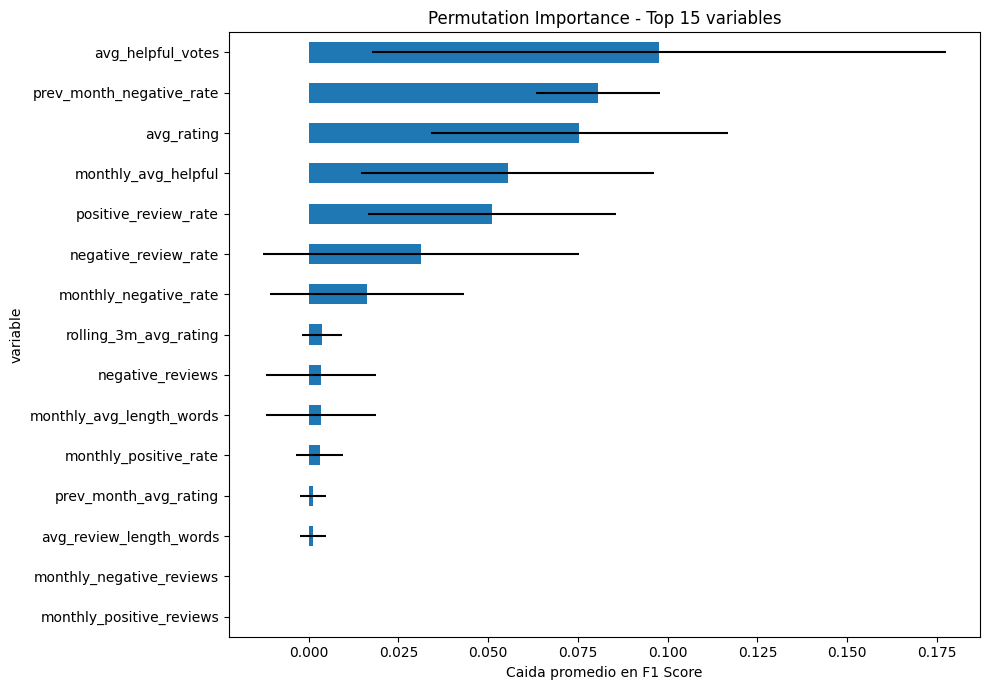

In [ ]:
#Permutation Importance

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

best_model = random_search_iteracion_1.best_estimator_

perm = permutation_importance(
    best_model,
    X_test_formal,
    y_test_formal,
    scoring="f1",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "variable": X_test_formal.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance.head(15))

perm_importance.head(15).sort_values("importance_mean").plot(
    x="variable",
    y="importance_mean",
    kind="barh",
    xerr="importance_std",
    figsize=(10, 7),
    legend=False,
    title="Permutation Importance - Top 15 variables"
)
plt.xlabel("Caida promedio en F1 Score")
plt.tight_layout()
plt.show()


##2. Variables eliminadas
El pipeline aplica selección de características mediante VarianceThreshold. Este paso elimina variables con varianza muy baja después de la imputación, encoding y escalado. En la práctica, suelen eliminarse columnas constantes, indicadores de nulos sin variación y categorías one-hot muy raras o sin presencia suficiente.
Estas variables eliminadas no aportan señales útiles al modelo y pueden aumentar ruido, dimensionalidad y riesgo de sobreajuste. El siguiente código permite listar las variables retenidas y eliminadas después del encoding y antes de PCA:


In [ ]:
pipe = random_search_iteracion_1.best_estimator_
encoder_step = pipe.named_steps["encoding"]
selector_step = pipe.named_steps["feature_selection"]

feature_names = encoder_step.get_feature_names_out()
selected_mask = selector_step.get_support()

variables_seleccionadas = pd.Series(feature_names[selected_mask], name="variables_seleccionadas")
variables_eliminadas = pd.Series(feature_names[~selected_mask], name="variables_eliminadas")

print("Variables antes de seleccion:", len(feature_names))
print("Variables seleccionadas:", len(variables_seleccionadas))
print("Variables eliminadas:", len(variables_eliminadas))

display(variables_eliminadas.head(30).to_frame())


Variables antes de seleccion: 116
Variables seleccionadas: 87
Variables eliminadas: 29


,variables_eliminadas
0,review_period_days_is_null
1,review_frequency_is_null
2,first_review_date_year_is_null
3,first_review_date_month_is_null
4,last_review_date_year_is_null
5,last_review_date_month_is_null
6,name_All-New Kindle Oasis E-reader - 7 High-Re...
7,name_All-New Kindle Oasis E-reader - 7 High-Re...
8,name_All-New Kindle Oasis E-reader - 7 High-Re...
9,name_All-new Echo (2nd Generation) with improv...


##3. Impacto de la selección de variables

| Impacto | Explicación |
|---|---|
| Reducción de ruido | Al eliminar columnas casi constantes, el modelo evita aprender señales incidentales o irrelevantes. |
| Mejor estabilidad | Reduce la sensibilidad del modelo a categorías escasas o columnas con información insuficiente. |
| Eficiencia computacional | Disminuye la cantidad de variables que pasan a PCA y Logistic Regression. |
| Interpretabilidad parcial | Permite documentar qué variables fueron descartadas antes de la reducción dimensional. |

,etapa,cantidad_variables
0,Antes de seleccion,116
1,Despues de seleccion,87


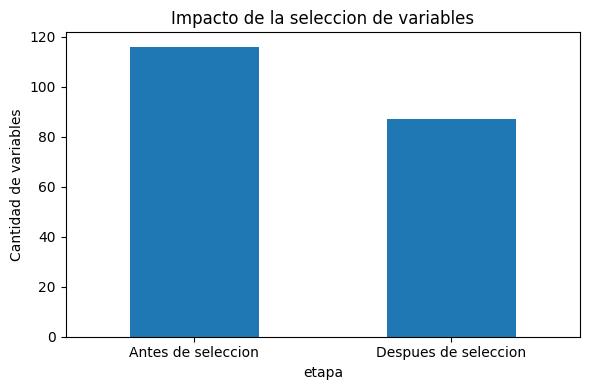

In [ ]:
#Variables antes vs. después

conteo_variables = pd.DataFrame({
    "etapa": ["Antes de seleccion", "Despues de seleccion"],
    "cantidad_variables": [len(feature_names), int(selected_mask.sum())]
})

display(conteo_variables)
conteo_variables.plot(
    x="etapa",
    y="cantidad_variables",
    kind="bar",
    legend=False,
    title="Impacto de la seleccion de variables",
    figsize=(6, 4)
)
plt.ylabel("Cantidad de variables")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##4. Impacto de PCA

PCA se utiliza como reducción dimensional después de la selección de características. Su principal impacto es transformar un conjunto amplio y potencialmente correlacionado de variables en componentes principales no correlacionados. Esto ayuda a estabilizar Logistic Regression y puede mejorar la generalización, especialmente cuando hay muchas variables creadas por One-Hot Encoding.
La desventaja es que PCA reduce la interpretabilidad directa: cada componente es una combinación lineal de muchas variables. Por eso, los coeficientes del modelo final deben interpretarse como importancia de componentes, no como importancia directa de variables originales.


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.825804,0.825804
1,PC2,0.112406,0.938210


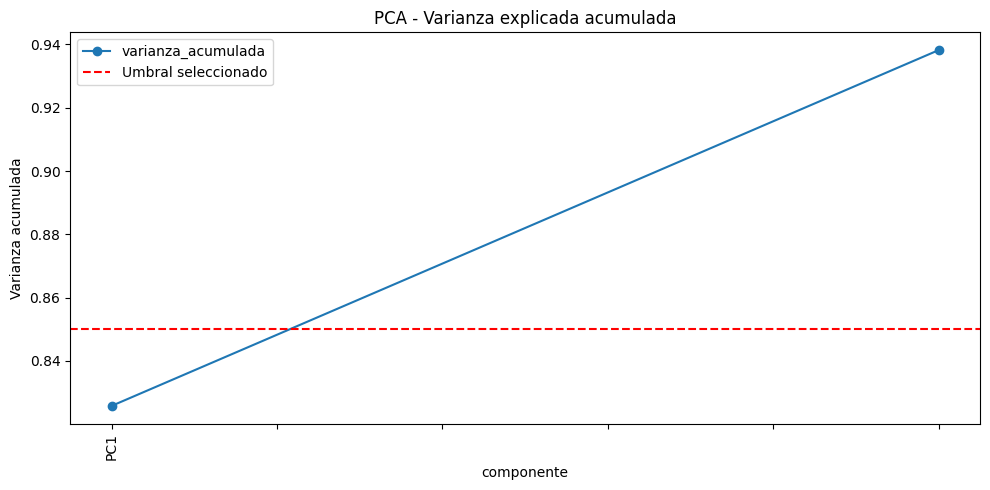

In [ ]:
#Varianza explicada por PCA

pca_step = random_search_iteracion_1.best_estimator_.named_steps["dimensionality_reduction"]

pca_summary = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(pca_step.explained_variance_ratio_))],
    "varianza_explicada": pca_step.explained_variance_ratio_,
    "varianza_acumulada": pca_step.explained_variance_ratio_.cumsum()
})

display(pca_summary.head(15))

pca_summary.plot(
    x="componente",
    y="varianza_acumulada",
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="PCA - Varianza explicada acumulada"
)
plt.axhline(0.85, linestyle="--", color="red", label="Umbral seleccionado")
plt.ylabel("Varianza acumulada")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

#Visualizacion de los datos en los dos primeros componentes principales.

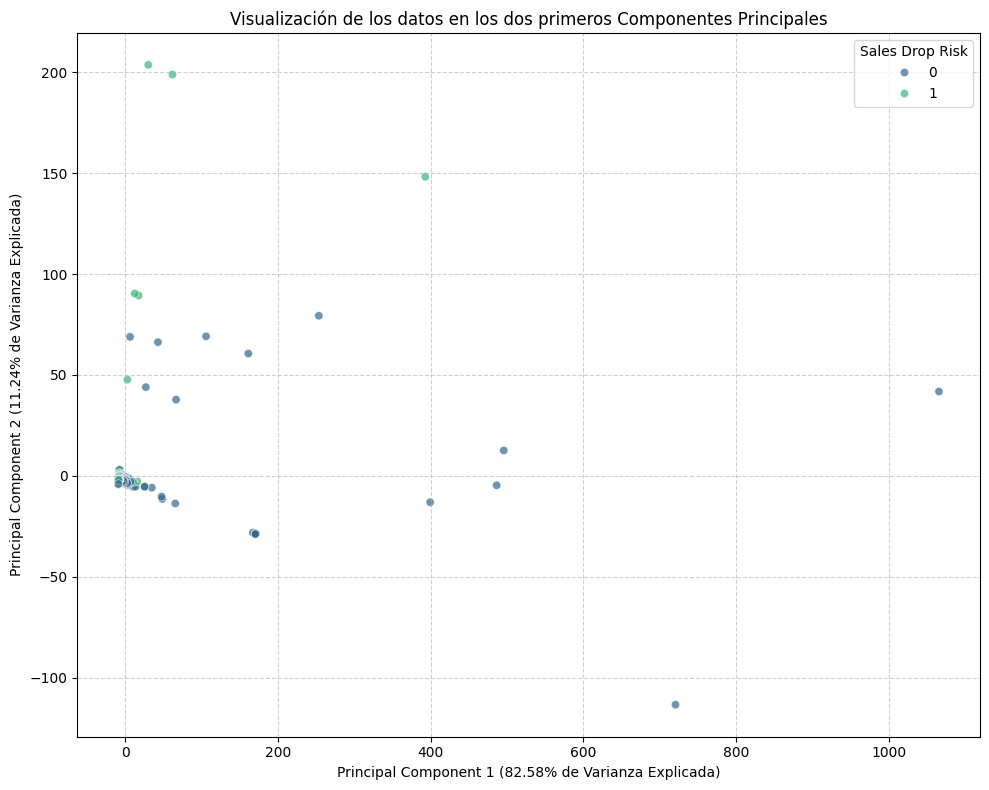

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from Iteration 1 (which was identified as the best overall)
best_pipeline = random_search_iteracion_1.best_estimator_

# Transform the full dataset up to the PCA step
X_transformed_pca = best_pipeline.named_steps['drop_duplicate_suffix_columns'].transform(X_formal)
X_transformed_pca = best_pipeline.named_steps['date_features'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['imputation'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['domain_features'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['encoding'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['scaling'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['feature_selection'].transform(X_transformed_pca)
X_transformed_pca = best_pipeline.named_steps['dimensionality_reduction'].transform(X_transformed_pca)

# Create a DataFrame for plotting the first two principal components
pca_df = pd.DataFrame(
    data=X_transformed_pca[:, 0:2],
    columns=['PC1', 'PC2']
)

# Add the target variable to the DataFrame
pca_df['sales_drop_risk'] = y_formal.values

# Plot the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='sales_drop_risk',
    data=pca_df,
    palette='viridis',
    alpha=0.7
)
plt.title('Visualización de los datos en los dos primeros Componentes Principales')
plt.xlabel(f'Principal Component 1 ({pca_step.explained_variance_ratio_[0]:.2%} de Varianza Explicada)')
plt.ylabel(f'Principal Component 2 ({pca_step.explained_variance_ratio_[1]:.2%} de Varianza Explicada)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Sales Drop Risk')
plt.tight_layout()
plt.show()

### Contribución de las características originales a PC1 y PC2

Los componentes principales (PC1 y PC2) son combinaciones lineales de las características originales. Para entender qué representa cada componente, examinamos los pesos (o *loadings*) que cada característica original tiene en ellos. Un peso más alto (en valor absoluto) indica una mayor contribución de esa característica al componente.

,monthly_reviews,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,prev_month_avg_rating,...,"name_Kindle Oasis E-reader with Leather Charging Cover - Walnut, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers","name_Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Free 3G + Wi-Fi - Includes Special Offers","name_Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers",brand_x_Amazon,brand_x_Amazonbasics,primaryCategories_x_Electronics,"primaryCategories_x_Electronics,Media",primaryCategories_x_Health & Beauty,"primaryCategories_x_Office Supplies,Electronics","primaryCategories_x_Toys & Games,Electronics"
PC1,-0.003609,-0.008224,-0.003603,-0.003689,0.987675,0.03467,0.009556,-0.003091,-0.001570,-0.005090,...,-0.000011,-0.00001,-0.000172,0.000502,-0.000493,0.000694,-0.000080,-0.000321,-0.000180,-0.000062
PC2,-0.005692,-0.004186,-0.005930,-0.007639,-0.151411,-0.00583,0.109582,-0.043428,-0.003256,-0.049451,...,-0.000097,-0.00011,-0.000389,0.000612,-0.000584,0.001387,-0.000333,-0.000304,-0.000417,-0.000157


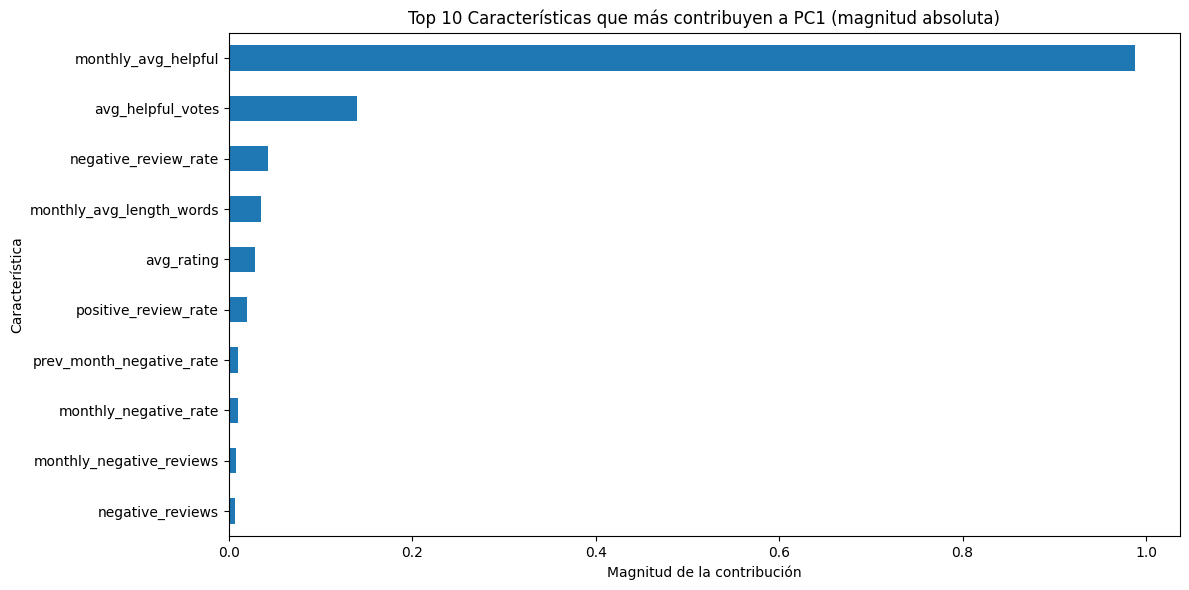

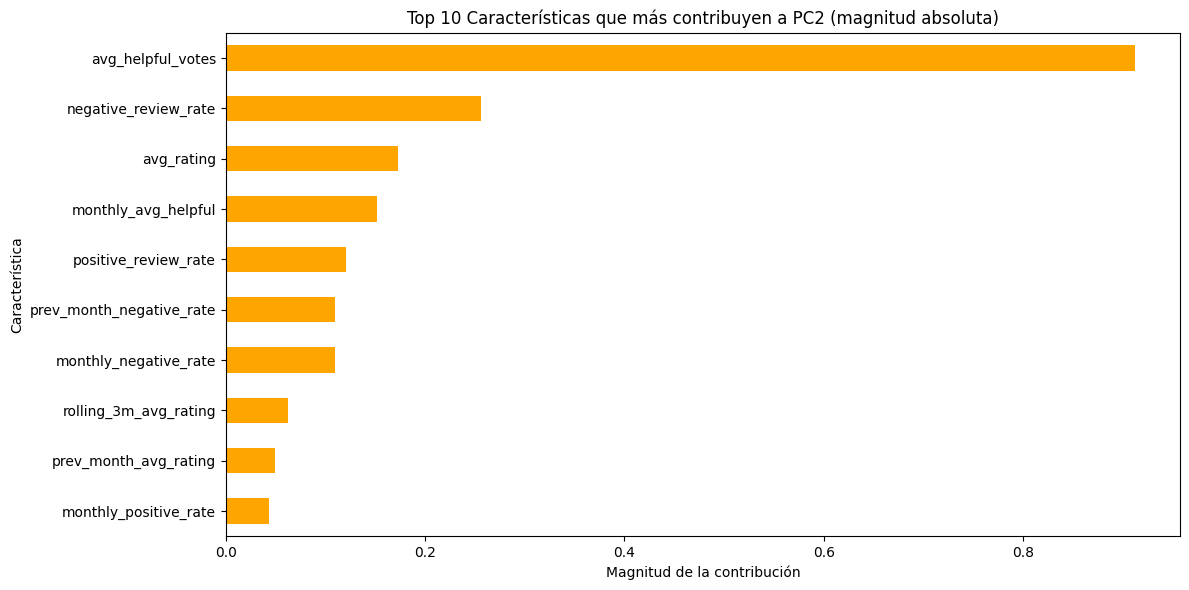

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from Iteration 1
best_pipeline = random_search_iteracion_1.best_estimator_

# Get the PCA step
pca_step = best_pipeline.named_steps['dimensionality_reduction']

# Get the feature names *before* PCA (after encoding and feature selection)
# Need to apply the pipeline steps up to feature selection to a dummy DataFrame
# to get the correct feature names.

# Create a temporary pipeline up to feature selection
preprocess_pipeline = Pipeline(steps=best_pipeline.steps[:-2]) # Exclude PCA and Logistic Regression

# Fit and transform a subset of the data to get the feature names after preprocessing
# It's important to use X_train_formal as it was used for fitting the pipeline
X_train_preprocessed = preprocess_pipeline.fit_transform(X_train_formal, y_train_formal)

# The feature names after encoding and feature selection are needed
# The last step in preprocess_pipeline is 'feature_selection'
# We need the feature names from the 'encoding' step first, then apply the selection mask

# Get feature names after encoding step
encoder_step = best_pipeline.named_steps['encoding']
# It's crucial to fit the encoder with the data it expects
X_temp_encoded = encoder_step.fit_transform(
    best_pipeline.named_steps['domain_features'].transform(
        best_pipeline.named_steps['imputation'].transform(
            best_pipeline.named_steps['date_features'].transform(
                best_pipeline.named_steps['drop_duplicate_suffix_columns'].transform(X_train_formal)
            )
        )
    )
)
original_feature_names_after_encoding = encoder_step.get_feature_names_out()

# Apply the feature selection mask from VarianceThreshold
selector_step = best_pipeline.named_steps['feature_selection']
selected_mask = selector_step.get_support()
feature_names_for_pca = original_feature_names_after_encoding[selected_mask]

# Create a DataFrame for the PCA components
# pca_step.components_ contains the principal components (eigenvectors)
# Each row is a principal component, each column is an original feature
components_df = pd.DataFrame(
    data=pca_step.components_,
    columns=feature_names_for_pca,
    index=[f'PC{i+1}' for i in range(pca_step.n_components_)]
)

display(components_df.head())

# Visualize the top contributing features for PC1
plt.figure(figsize=(12, 6))
components_df.loc['PC1'].abs().sort_values(ascending=False).head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Características que más contribuyen a PC1 (magnitud absoluta)')
plt.xlabel('Magnitud de la contribución')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Visualize the top contributing features for PC2
plt.figure(figsize=(12, 6))
components_df.loc['PC2'].abs().sort_values(ascending=False).head(10).sort_values().plot(kind='barh', color='orange')
plt.title('Top 10 Características que más contribuyen a PC2 (magnitud absoluta)')
plt.xlabel('Magnitud de la contribución')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

##5. Coeficientes del modelo

Como el modelo final es Logistic Regression después de PCA, sus coeficientes indican que los componentes principales aumentan o reducen la probabilidad estimada de riesgo. Coeficientes positivos elevan la probabilidad de sales_drop_risk=1; coeficientes negativos la reducen.


,componente,coeficiente,abs_coeficiente
1,PC2,0.011693,0.011693
0,PC1,0.000000,0.000000


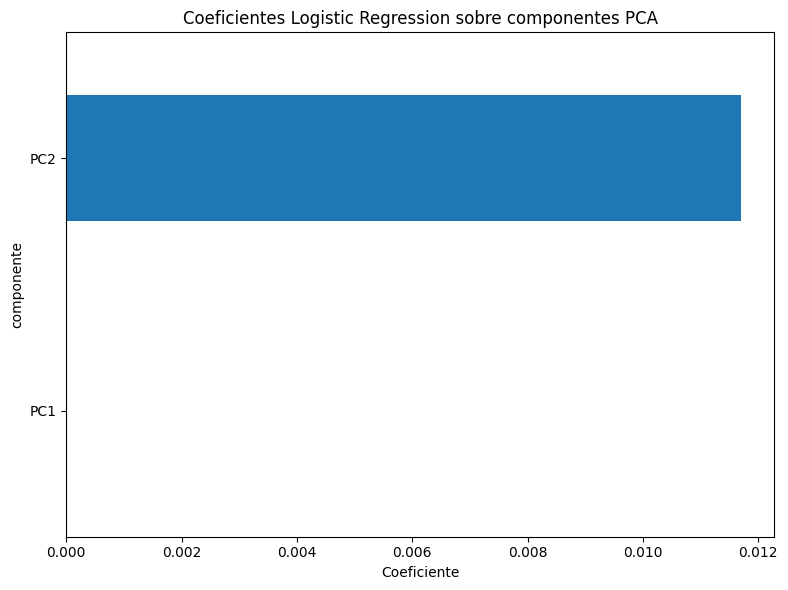

In [ ]:
model_step = random_search_iteracion_1.best_estimator_.named_steps["training"]
pca_step = random_search_iteracion_1.best_estimator_.named_steps["dimensionality_reduction"]

coeficientes = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(model_step.coef_[0]))],
    "coeficiente": model_step.coef_[0]
})
coeficientes["abs_coeficiente"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("abs_coeficiente", ascending=False)

display(coeficientes.head(15))

coeficientes.head(15).sort_values("coeficiente").plot(
    x="componente",
    y="coeficiente",
    kind="barh",
    figsize=(8, 6),
    legend=False,
    title="Coeficientes Logistic Regression sobre componentes PCA"
)
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()


El resultado que se muestra en el DataFrame de coeficientes y el gráfico de barras adjunto ilustra la influencia de cada Componente Principal (CP) en la predicción del modelo sobre el riesgo de caída de ventas. Analicemos cada componente:

**Componente:** Esta columna indica el Componente Principal (p. ej., CP1, CP2). Cada CP es una combinación lineal de varias características originales, diseñada para capturar la mayor varianza posible en los datos.

**Coeficiente:** Este es el coeficiente que el modelo de Regresión Logística asigna a cada Componente Principal correspondiente. En un modelo de Regresión Logística, un coeficiente positivo significa que, a medida que aumenta el valor de dicho componente, la probabilidad estimada de que el riesgo de caída de ventas sea igual a 1 también aumenta. Por el contrario, un coeficiente negativo significa que, a medida que aumenta el valor del componente, la probabilidad de una caída de ventas disminuye.

**Coeficiente absoluto:** Esta columna muestra el valor absoluto del coeficiente. Permite identificar rápidamente qué componentes tienen la mayor influencia en la predicción del modelo, independientemente de si dicha influencia es positiva o negativa. Según los resultados:

El Componente Principal 2 (PC2) tiene un coeficiente de 0,011693 (positivo), lo que indica que valores más altos en este componente se asocian con una probabilidad ligeramente mayor de una caída en las ventas.

El Componente Principal 1 (PC1) tiene un coeficiente de 0,000000 (cero), lo que indica que no tiene un impacto lineal directo en la probabilidad predicha de una caída en las ventas en este modelo en particular. Esto podría deberse a que su varianza está representada por otros componentes o a efectos de regularización/selección de características.

El gráfico de barras representa visualmente estos coeficientes, lo que permite observar fácilmente la fuerza relativa y la dirección del impacto de cada componente. Cuanto más larga sea la barra (ya sea positiva o negativa), mayor será la influencia de ese Componente Principal en la predicción del riesgo de caída de ventas del modelo.

#6. SHAP

SHAP puede utilizarse como análisis complementario, pero en este pipeline su lectura directa queda afectada por PCA. Si se aplica SHAP sobre el espacio transformado, se explican los componentes principales. Al explicar variables originales, es preferible priorizar Permutation Importance sobre el pipeline completo.


#Conclusión de interpretabilidad

El modelo optimizado identifica el riesgo principalmente a partir de señales de deterioro en calificaciones y reseñas negativas. La selección de variables reduce columnas poco informativas, mientras que PCA mejora la estabilidad y reduce dimensionalidad a costa de interpretabilidad directa. Por esta razón, la interpretación recomendada debe combinar Permutation Importance para variables originales con coeficientes del modelo sobre componentes PCA. La principal limitación es que el target fue construido como proxy a partir de variables de reserva, por lo que algunas importancias reflejan la propia regla de construcción del riesgo.
